# Phenology Prediction Results Overview

Results across three temporal configurations:
- **4 months** (quarterly: Mar, Jun, Sep, Dec)
- **8 months** (growing season: Mar–Oct)
- **12 months** (all months)

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os
import path_config
from lib.utils_plotting import results_file, add_region_to_results, sort_df

sns.set_theme()

# Date display names and column prefix mapping
DATE_NAMES = ["Greenup", "Maturity", "Senescence", "Dormancy"]
DATE_SHORT = ["G", "M", "S", "D"]  # column prefixes in CSVs
DATE_MAP = dict(zip(DATE_NAMES, DATE_SHORT))


MONTH_SUBSETS = {
    4: [3, 6, 9, 12],
    8: [3, 4, 5, 6, 7, 8, 9, 10],
    12: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
}

METHODS_TABLE = [
    "random_baseline_1.0_test",
    "transformer_1d_paper_nl3_1.0_test",
    "prithvi_final_100m_crop32_1.0_test",
    "transformer_1d_priorwork_data_test",
    "presto_1.0_test", 
]

# Load prior work CSV from parent results folder (not month-specific)
PRIOR_WORK_KEY = "transformer_1d_priorwork_data_test"
prior_work_csv = os.path.join("results", f"{PRIOR_WORK_KEY}.csv")
prior_work_df = sort_df(pd.read_csv(prior_work_csv))
prior_work_df_w_regions = add_region_to_results(
    results_df=prior_work_df,
    geo_path=path_config.get_data_geojson(),
    eco_path="useco1/NA_CEC_Eco_Level1.shp",
    region_column="NA_L1NAME",
)

all_results = {}
all_results_w_regions = {}
all_results_val = {}
all_results_w_regions_val = {}
all_mae_dfs = {}
all_results_per_seed = {}
CANONICAL_SEEDS = ["seed_42", "seed_123", "seed_456"]

for n_months, months in MONTH_SUBSETS.items():
    print(f"Loading {n_months}-month subset...", end=" ")
    res_test, res_w_reg_test, res_per_seed_test = results_file("test", selected_months=months, seeds=CANONICAL_SEEDS)
    res_val, res_w_reg_val, _ = results_file("val", selected_months=months, seeds=CANONICAL_SEEDS)

    # Inject prior work results (same for all subsets)
    res_test[PRIOR_WORK_KEY] = prior_work_df
    res_w_reg_test[PRIOR_WORK_KEY] = prior_work_df_w_regions

    all_results[n_months] = res_test
    all_results_w_regions[n_months] = res_w_reg_test
    all_results_val[n_months] = res_val
    all_results_w_regions_val[n_months] = res_w_reg_val
    all_results_per_seed[n_months] = res_per_seed_test

    # Build per-tile MAE averaged across seeds
    mae_dict = {"HLStile": [], "Date": [], "MAE": [], "Method": [], "SiteID": [], "years": []}
    ref_key = list(res_w_reg_test.keys())[0]
    tile_info = res_w_reg_test[ref_key][["HLStile", "SiteID", "years"]].drop_duplicates().values

    for key in res_w_reg_test.keys():
        seed_dfs = res_per_seed_test.get(key, [res_w_reg_test[key]])
        for tile, siteid, year in tile_info:
            seed_tile_maes = {d: [] for d in DATE_SHORT}
            for sdf in seed_dfs:
                df_tile = sdf[(sdf["HLStile"] == tile) & (sdf["SiteID"] == siteid) & (sdf["years"] == year)]
                if len(df_tile) == 0:
                    continue
                for d in DATE_SHORT:
                    seed_tile_maes[d].append(np.mean(np.abs(df_tile[f"{d}_pred_DOY"] - df_tile[f"{d}_truth_DOY"])))
            for d_short, d_name in zip(DATE_SHORT, DATE_NAMES):
                if seed_tile_maes[d_short]:
                    mae_dict["HLStile"].append(tile)
                    mae_dict["Date"].append(d_name)
                    mae_dict["MAE"].append(np.mean(seed_tile_maes[d_short]))
                    mae_dict["SiteID"].append(siteid)
                    mae_dict["years"].append(year)
                    mae_dict["Method"].append(key)

    all_mae_dfs[n_months] = pd.DataFrame(mae_dict)
    print("done.")

print("All subsets loaded.")

Loading 4-month subset... 

done.
Loading 8-month subset... 

done.
Loading 12-month subset... 

done.
All subsets loaded.


In [2]:
import subprocess, tempfile, os
from IPython.display import display, Image

def render_latex_preview(latex_str, dpi=200):
    """Compile a LaTeX snippet to PDF, convert to PNG, and display inline."""
    doc = r"""\documentclass[final,3p,times,twocolumn]{elsarticle}
\usepackage{amssymb}
\usepackage{amsmath}
\usepackage{booktabs}
\usepackage{multirow}
\makeatletter
\def\@author{}
\def\@title{}
\makeatother
\begin{document}
""" + latex_str + r"""
\end{document}"""
    
    with tempfile.TemporaryDirectory() as tmpdir:
        # Copy elsarticle.cls to tmpdir
        import shutil
        cls_src = os.path.join("paper_latex", "elsarticle.cls")
        if os.path.exists(cls_src):
            shutil.copy(cls_src, tmpdir)
        
        tex_path = os.path.join(tmpdir, "preview.tex")
        with open(tex_path, "w") as f:
            f.write(doc)
        cmd = f"module load texlive/2023 && pdflatex -interaction=nonstopmode -output-directory {tmpdir} {tex_path}"
        result = subprocess.run(cmd, shell=True, executable="/bin/bash", capture_output=True, text=True)
        pdf_path = os.path.join(tmpdir, "preview.pdf")
        if not os.path.exists(pdf_path):
            print("LaTeX compilation failed:")
            # Show just the error
            for line in result.stdout.split('\n'):
                if line.startswith('!') or 'Error' in line:
                    print(line)
            return
        png_path = os.path.join(tmpdir, "preview")
        subprocess.run(["pdftoppm", "-png", "-r", str(dpi), pdf_path, png_path], capture_output=True)
        png_file = png_path + "-1.png"
        if os.path.exists(png_file):
            display(Image(filename=png_file))
            # Also save PDF copy for inspection
            import shutil
            shutil.copy(pdf_path, "paper_latex/Images/_preview.pdf")
        else:
            print("PNG conversion failed")


## 1. Performance vs. Number of Input Months

Grouped bar chart comparing models across 4, 8, and 12 input months, with efficiency panel.

In [3]:
methods_compare = {
    "Temporal Transformer": "transformer_1d_paper_nl3_1.0_test",
    "Presto": "presto_1.0_test",
    "Prithvi": "prithvi_final_100m_crop32_1.0_test",
    "Ensemble (all)": "ensemble_all_test",
}

dates = ["Greenup", "Maturity", "Senescence", "Dormancy"]
n_months_list = sorted(MONTH_SUBSETS.keys())

# Build comparison dataframe from per-seed, per-tile MAEs (mean and std across seeds)
rows = []
for n_months in n_months_list:
    per_seed = all_results_per_seed.get(n_months, {})
    ref_key = list(all_results[n_months].keys())[0]
    tile_info = all_results[n_months][ref_key][["HLStile", "SiteID", "years"]].drop_duplicates().values

    for name, key in methods_compare.items():
        seed_dfs = per_seed.get(key, [])
        if not seed_dfs:
            continue
        seed_maes = []
        for sdf in seed_dfs:
            tile_maes = {d: [] for d in DATE_NAMES}
            for tile, siteid, year in tile_info:
                df_tile = sdf[(sdf["HLStile"] == tile) & (sdf["SiteID"] == siteid) & (sdf["years"] == year)]
                if len(df_tile) == 0:
                    continue
                for d_name, d_short in zip(DATE_NAMES, DATE_SHORT):
                    tile_maes[d_name].append(np.mean(np.abs(df_tile[f"{d_short}_pred_DOY"] - df_tile[f"{d_short}_truth_DOY"])))
            sm = {}
            for d_name in DATE_NAMES:
                sm[d_name] = np.mean(tile_maes[d_name]) if tile_maes[d_name] else 0.0
            sm["Mean"] = np.mean([sm[d] for d in DATE_NAMES])
            seed_maes.append(sm)
        for d in DATE_NAMES + ["Mean"]:
            vals = [sm[d] for sm in seed_maes]
            rows.append({"Months": n_months, "Method": name, "Date": d,
                         "MAE": np.mean(vals), "Std": np.std(vals) if len(vals) > 1 else 0.0})

comp_df = pd.DataFrame(rows)

# Prior work MAE (fixed reference — same data for all subsets)
prior_mae = {}
mdf_ref = all_mae_dfs[n_months_list[-1]]
for d in dates:
    prior_mae[d] = mdf_ref[(mdf_ref["Method"] == PRIOR_WORK_KEY) & (mdf_ref["Date"] == d)]["MAE"].mean()
prior_mae["Mean"] = mdf_ref[mdf_ref["Method"] == PRIOR_WORK_KEY]["MAE"].mean()

# --- Load benchmark results ---
bench_df = pd.read_csv("results/benchmark_results.csv")
bench_mean = bench_df.groupby(["Model", "Timesteps"])["Time (s)"].mean().reset_index()

bench_to_label = {
    "1D Transformer": "Temporal Transformer",
    "Prithvi (100M, crop32)": "Prithvi",
    "Presto": "Presto",
    "Ensemble (all)": "Ensemble (all)",
}


# --- Plot: 2x3 layout (G, M / S, D / Mean, Efficiency) ---
from matplotlib.gridspec import GridSpec

sns.set_theme(style="whitegrid")

COL_GAP = 0.01
fig = plt.figure(figsize=(19, 7))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, COL_GAP, 1],
              wspace=0.18, hspace=0.5)

axes = np.empty((2, 3), dtype=object)
axes[0, 0] = fig.add_subplot(gs[0, 0])
axes[0, 1] = fig.add_subplot(gs[0, 1])
axes[1, 0] = fig.add_subplot(gs[1, 0])
axes[1, 1] = fig.add_subplot(gs[1, 1])
axes[0, 2] = fig.add_subplot(gs[0, 3])
# Efficiency panel: narrower than its cell, centered within it
eff_outer = gs[1, 3].get_position(fig)
eff_shrink = 0.35
eff_w = eff_outer.width * (1 - eff_shrink)
eff_x = eff_outer.x0 + (eff_outer.width - eff_w) / 2
axes[1, 2] = fig.add_axes([eff_x, eff_outer.y0, eff_w, eff_outer.height])

panel_positions = [(0,0), (0,1), (1,0), (1,1), (0,2)]
colors = sns.color_palette("Set2", len(methods_compare))
method_names = list(methods_compare.keys())
n_methods = len(method_names)
group_spacing = 1.05
x = np.arange(len(n_months_list)) * group_spacing
bar_width_frac = 0.97
bar_width = bar_width_frac / n_methods

for idx, d in enumerate(dates + ["Mean"]):
    ax = axes[panel_positions[idx]]
    # Panel y-range floats with data
    panel_vals, panel_stds = [], []
    for name in method_names:
        sub = comp_df[(comp_df["Method"] == name) & (comp_df["Date"] == d)]
        for m in n_months_list:
            panel_vals.append(sub[sub["Months"] == m]["MAE"].values[0])
            panel_stds.append(sub[sub["Months"] == m]["Std"].values[0])
    y_lo = min(panel_vals) - 0.8
    y_hi = max(v + s for v, s in zip(panel_vals, panel_stds)) + 0.6

    for i, name in enumerate(method_names):
        sub = comp_df[(comp_df["Method"] == name) & (comp_df["Date"] == d)]
        vals = [sub[sub["Months"] == m]["MAE"].values[0] for m in n_months_list]
        stds = [sub[sub["Months"] == m]["Std"].values[0] for m in n_months_list]
        is_ensemble = (name == "Ensemble (all)")
        edge_width = 1.4 if is_ensemble else 0.7
        bars = ax.bar(x + i * bar_width - (n_methods - 1) * bar_width / 2, vals,
                      bar_width, label=name if idx == 0 else None, color=colors[i],
                      yerr=stds, capsize=2.5, error_kw={"linewidth": 0.9},
                      edgecolor="black", linewidth=edge_width, zorder=3)
    ax.axhline(y=prior_mae[d], color="#444444", linestyle=(0, (3, 2)), linewidth=1.8,
               label="Temporal Transformer (T = 244)" if idx == 0 else None, zorder=2)

    ax.set_title(d, fontsize=14, fontweight="bold" if d == "Mean" else "normal")
    ax.set_xlabel("# Input Months")
    ax.set_xticks(x)
    ax.set_xticklabels(n_months_list)
    half_span = bar_width * n_methods / 2
    ax.set_xlim(x[0] - half_span - 0.02, x[-1] + half_span + 0.02)
    ax.set_ylim(y_lo, y_hi)
    if idx == 0:
        ax.set_ylabel("MAE (days)")
    # Fine-grained y grid: major (labelled) every 0.5, minor every 0.25
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.25))
    ax.grid(axis="y", which="major", linestyle="-", linewidth=0.8, alpha=0.5, color="#888888")
    ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.5, alpha=0.4, color="#aaaaaa")
    ax.tick_params(axis="y", which="major", labelsize=9)
    ax.set_axisbelow(True)

# Efficiency panel (bottom-right, narrower)
ax = axes[1, 2]
bench_colors = {
    "Temporal Transformer": colors[0],
    "Presto":               colors[1],
    "Prithvi":              colors[2],
    "Ensemble (all)":       colors[3],
}
bench_markers = {"Temporal Transformer": "s", "Prithvi": "o", "Presto": "D", "Ensemble (all)": "^"}

for model_name in bench_mean["Model"].unique():
    label = bench_to_label.get(model_name, model_name)
    if label not in bench_colors:
        continue
    sub = bench_mean[bench_mean["Model"] == model_name].sort_values("Timesteps")
    sub = sub[sub["Timesteps"].isin([4, 8, 12])]
    if len(sub) == 0:
        continue
    ax.plot(sub["Timesteps"], sub["Time (s)"], marker=bench_markers[label],
            color=bench_colors[label], linewidth=2, markersize=7, label=label)

prior_bench = bench_mean[(bench_mean["Model"] == "1D Transformer") & (bench_mean["Timesteps"] == 244)]
if len(prior_bench) > 0:
    prior_time_val = prior_bench["Time (s)"].values[0]
    ax.axhline(y=prior_time_val, color="#444444", linestyle=(0, (3, 2)), linewidth=1.8, zorder=2)
    ax.text(ax.get_xlim()[0] + 0.5, prior_time_val + 0.08, "T = 244",
            color="#444444", fontsize=9, fontweight="bold", va="bottom")

ax.set_title("Efficiency", fontsize=14, fontweight="bold")
ax.set_xlabel("# Input Timesteps")
ax.set_xticks(n_months_list)
ax.set_ylabel("Inference Time / Tile (s)")
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.1))
ax.grid(axis="y", which="major", linestyle="-", linewidth=0.8, alpha=0.5, color="#888888")
ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.5, alpha=0.4, color="#aaaaaa")
ax.set_axisbelow(True)

handles, labels = axes[0, 0].get_legend_handles_labels()
h6, l6 = axes[1, 2].get_legend_handles_labels()
seen = set(labels)
for h, l in zip(h6, l6):
    if l not in seen:
        handles.append(h)
        labels.append(l)
        seen.add(l)

fig.legend(handles, labels, loc="lower center", ncol=len(handles),
           bbox_to_anchor=(0.5, -0.08), fontsize=14)
plt.show()


In [4]:
# Save figure
fig.savefig("paper_latex/Images/performance_vs_months.pdf", bbox_inches="tight", dpi=300)
print("Saved: paper_latex/Images/performance_vs_months.pdf")

Saved: paper_latex/Images/performance_vs_months.pdf


## 3. Effect of Crop Size on Prithvi

In [5]:
# ============================================================
# Change this to analyze a different subset, then re-run below
SELECTED_MONTHS = [3, 6, 9, 12]       
# Options:
#   [3, 6, 9, 12]                            -- 4 months
#   [3, 4, 5, 6, 7, 8, 9, 10]                -- 8 months
#   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  -- 12 months
# ============================================================

n_sel = len(SELECTED_MONTHS)
mae_df = all_mae_dfs[n_sel]
sel_results = all_results[n_sel]
sel_results_w_regions = all_results_w_regions[n_sel]
sel_results_val = all_results_val[n_sel]
ensemble_key = "ensemble_multiscale_crop32_transformer_1d_paper_test"

print(f"Detailed analysis for {n_sel} months: {SELECTED_MONTHS}")

Detailed analysis for 4 months: [3, 6, 9, 12]


In [6]:
crop_methods = {
    16:  "prithvi_final_100m_crop16_1.0_test",
    32:  "prithvi_final_100m_crop32_1.0_test",
    48:  "prithvi_final_100m_crop48_1.0_test",
    96:  "prithvi_final_100m_crop96_1.0_test",
    144: "prithvi_final_100m_crop144_1.0_test",
    224: "prithvi_final_100m_crop224_1.0_test",
}

crop_dates = ["Greenup", "Maturity", "Senescence", "Dormancy"]
crop_sizes = sorted(crop_methods.keys())

mae_per_date = {d: [] for d in crop_dates}
mae_mean = []

for cs in crop_sizes:
    df_crop = mae_df[mae_df["Method"] == crop_methods[cs]]
    for d in crop_dates:
        mae_per_date[d].append(df_crop[df_crop["Date"] == d]["MAE"].mean())
    mae_mean.append(df_crop["MAE"].mean())

# --- Match main-figure style ---
sns.set_theme(style="whitegrid")

n_methods = len(crop_dates)
group_spacing = 1.05
bar_width_frac = 0.78
bar_width = bar_width_frac / n_methods
x = np.arange(len(crop_sizes)) * group_spacing

colors_bar = sns.color_palette("Set2", n_methods)

# Column-friendly sizing: width matches legend below the plot
fig, ax = plt.subplots(figsize=(4.2, 2.6))

# Floating y-limits based on data
all_vals = [v for d in crop_dates for v in mae_per_date[d]] + list(mae_mean)
y_lo = min(all_vals) - 0.6
y_hi = max(all_vals) + 0.7

for i, d in enumerate(crop_dates):
    positions = x + i * bar_width - (n_methods - 1) * bar_width / 2
    ax.bar(positions, mae_per_date[d], bar_width,
           label=d, color=colors_bar[i],
           edgecolor="black", linewidth=0.5, zorder=3)

# Mean line across group centers
ax.plot(x, mae_mean, marker="o", color="black",
        linewidth=1.4, markersize=4, label="Mean", zorder=5)
for xv, mv in zip(x, mae_mean):
    ax.text(xv, mv + 0.18, f"{mv:.1f}", ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="black", zorder=6,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                      edgecolor="black", linewidth=0.5))

ax.set_xticks(x)
ax.set_xticklabels([str(cs) for cs in crop_sizes], fontsize=9)
half_span = bar_width * n_methods / 2
ax.set_xlim(x[0] - half_span - 0.02, x[-1] + half_span + 0.02)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel("Crop Size (pixels)", fontsize=10)
ax.set_ylabel("MAE (days)", fontsize=10)

# Fine-grained y grid: major (labelled) every 1.0, minor every 0.5
ax.yaxis.set_major_locator(plt.MultipleLocator(1.0))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.grid(axis="y", which="major", linestyle="-", linewidth=0.6, alpha=0.5, color="#888888")
ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.4, alpha=0.4, color="#aaaaaa")
ax.tick_params(axis="y", which="major", labelsize=9)
ax.set_axisbelow(True)

# Legend below the plot, single row of 5
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), fontsize=8, ncol=5, frameon=True,
          handlelength=1.0, handletextpad=0.4, columnspacing=0.9,
          borderpad=0.3)

plt.tight_layout(pad=0.3)
fig.savefig("paper_latex/Images/crop_size_effect.pdf", bbox_inches="tight", dpi=300)
print("Saved: paper_latex/Images/crop_size_effect.pdf")
plt.show()

Saved: paper_latex/Images/crop_size_effect.pdf


## 4. Regional Performance Table

Per-tile MAE across models and month subsets for selected tiles.
**Bold** = best model per column, \underline{underlined} = second best.

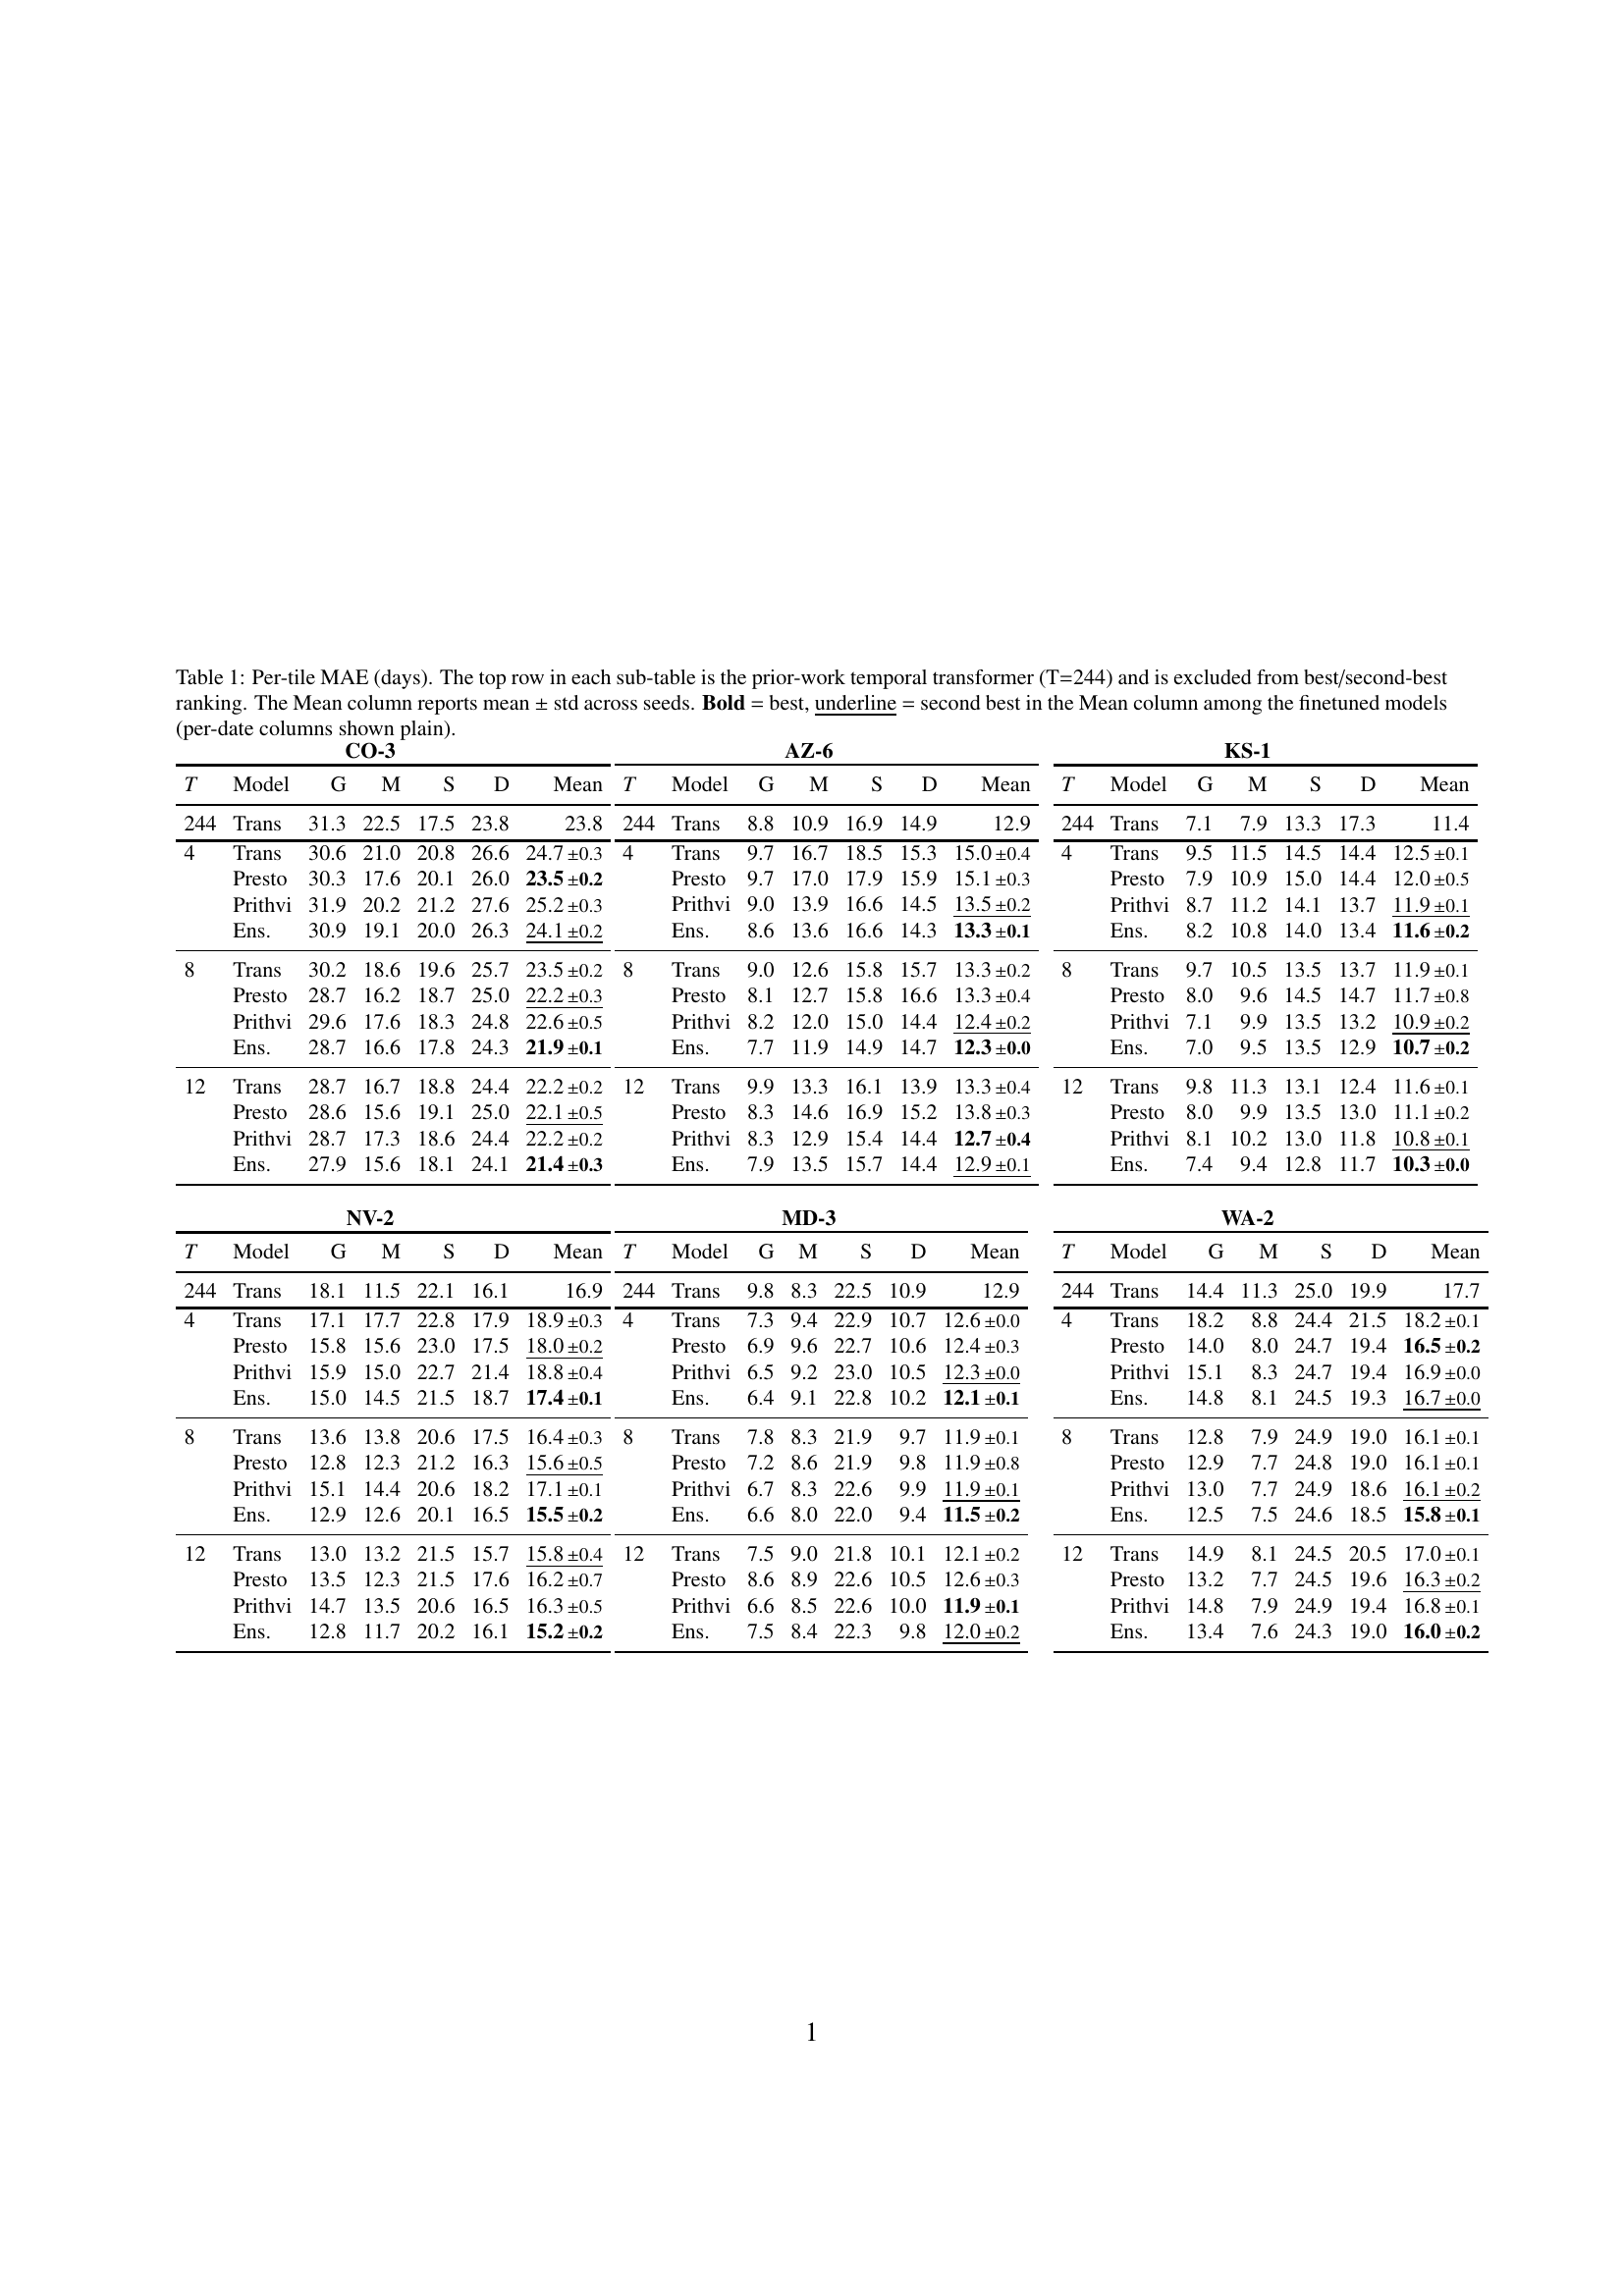

In [7]:
import geopandas as gpd

heatmap_methods = {"Trans":"transformer_1d_paper_nl3_1.0_test","Presto":"presto_1.0_test",
                   "Prithvi":"prithvi_final_100m_crop32_1.0_test",
                   "Ens.":"ensemble_all_test"}
model_names = list(heatmap_methods.keys())
month_subsets_sorted = sorted(MONTH_SUBSETS.keys())
month_names = {4:"4", 8:"8", 12:"12"}

selected_tiles = [
    # Illustrative tiles across the 4/8/12-month subsets. MD-3 and WA-2 were
    # selected jointly as the unused pair closest to the test-set-average profile
    # of baseline difficulty and Presto, Prithvi, and ensemble improvements.
    ("CO-3","T13TDE"),("AZ-6","T12SWA"),("KS-1","T15SUD"),
    ("NV-2","T11SQD"),("MD-3","T18SUJ"),("WA-2","T10TER"),
]


def _per_seed_tile_stats(seed_dfs, siteid, hls_tile):
    """For a given (SiteID, HLStile), compute per-seed (G,M,S,D,Mean) MAE."""
    out = []
    for sdf in seed_dfs:
        df_t = sdf[(sdf["SiteID"] == siteid) & (sdf["HLStile"] == hls_tile)]
        if len(df_t) == 0:
            continue
        sm = {}
        for d_name, d_short in zip(DATE_NAMES, DATE_SHORT):
            sm[d_name] = float(np.mean(np.abs(
                df_t[f"{d_short}_pred_DOY"] - df_t[f"{d_short}_truth_DOY"])))
        sm["Mean"] = float(np.mean([sm[d] for d in DATE_NAMES]))
        out.append(sm)
    return out


# Pre-compute per-(siteid, tile, T, model) aggregate (mean for each col, std for Mean)
# tile_data[(siteid, tile)][(model, nm)] = {date: mean, "Mean": mean, "Mean_std": std}
tile_data = {}
for nm in month_subsets_sorted:
    per_seed = all_results_per_seed.get(nm, {})
    for ml, mk in heatmap_methods.items():
        seed_dfs = per_seed.get(mk, [])
        if not seed_dfs:
            continue
        for siteid, hls_tile in selected_tiles:
            samples = _per_seed_tile_stats(seed_dfs, siteid, hls_tile)
            if not samples:
                continue
            agg = {d: float(np.mean([s[d] for s in samples])) for d in DATE_NAMES}
            means = np.array([s["Mean"] for s in samples])
            agg["Mean"] = float(means.mean())
            agg["Mean_std"] = float(means.std(ddof=1)) if len(means) > 1 else 0.0
            k = (siteid, hls_tile)
            if k not in tile_data: tile_data[k] = {}
            tile_data[k][(ml, nm)] = agg

# Prior work: same across month subsets, no std (single reference run)
# Pool both years per tile, exactly like the per-seed model rows above.
prior_tile_data = {}
for siteid, hls_tile in selected_tiles:
    df_t = prior_work_df[(prior_work_df["SiteID"] == siteid) & (prior_work_df["HLStile"] == hls_tile)]
    if len(df_t) == 0:
        continue
    prior_tile_data[(siteid, hls_tile)] = {
        d_name: float(np.mean(np.abs(df_t[f"{d_short}_pred_DOY"] - df_t[f"{d_short}_truth_DOY"])))
        for d_name, d_short in zip(DATE_NAMES, DATE_SHORT)
    }


def _fmt_mean_std(m, sd):
    return f"{m:.1f}{{\\scriptsize\\,$\\pm${sd:.1f}}}"


tiles_per_row = 3
L = []
L.append(r"\begin{table*}[!t]")
L.append(r"\centering")
L.append(r"\caption{Per-tile MAE (days). The top row in each sub-table is the prior-work temporal transformer (T{=}244) and is excluded from best/second-best ranking. The Mean column reports mean $\pm$ std across seeds. \textbf{Bold} = best, \underline{underline} = second best in the Mean column among the fine-tuned models.}")
L.append(r"\label{tab:tile_performance}")
L.append(r"\setlength{\tabcolsep}{3pt}")
L.append(r"\footnotesize")

for tile_row_start in range(0, len(selected_tiles), tiles_per_row):
    tile_row = selected_tiles[tile_row_start:tile_row_start+tiles_per_row]
    if tile_row_start > 0:
        L.append(r"")
        L.append(r"\vspace{8pt}")
        L.append(r"")
    for ti, (siteid, tile) in enumerate(tile_row):
        if ti > 0:
            L.append(r"\hfill")
        L.append(r"\begin{minipage}{0.31\textwidth}")
        L.append(r"\centering")
        L.append(r"{\bfseries " + siteid + "}")
        L.append(r"\vspace{1pt}")
        L.append("")
        L.append(r"\begin{tabular}{llrrrrr}")
        L.append(r"\toprule")
        L.append(r"$T$ & Model & G & M & S & D & Mean \\")
        L.append(r"\midrule")

        # Prior-work row (no std, no ranking)
        prior_vals = prior_tile_data.get((siteid, tile), {d: float("nan") for d in DATE_NAMES})
        prior_list = [prior_vals[d] for d in DATE_NAMES]
        prior_valid = [v for v in prior_list if not np.isnan(v)]
        prior_mean = np.mean(prior_valid) if prior_valid else float("nan")
        prior_cells = ["244", "Trans"]
        for v in prior_list + [prior_mean]:
            prior_cells.append("---" if np.isnan(v) else f"{v:.1f}")
        L.append(" & ".join(prior_cells) + r" \\")
        L.append(r"\specialrule{1.2pt}{0pt}{0pt}")

        for ni, nm in enumerate(month_subsets_sorted):
            # Build row dicts for ranking on Mean
            mean_ci = 4
            model_vals = {}
            for model in model_names:
                cell_agg = tile_data.get((siteid, tile), {}).get((model, nm))
                if cell_agg is None:
                    model_vals[model] = ([float("nan")] * 4 + [float("nan")], 0.0)
                else:
                    vals = [cell_agg[d] for d in DATE_NAMES] + [cell_agg["Mean"]]
                    model_vals[model] = (vals, cell_agg["Mean_std"])

            # Best/second only for Mean column (ci=4) among finetuned models
            fmt = {}
            mean_pairs = [(m, model_vals[m][0][mean_ci]) for m in model_names
                          if not np.isnan(model_vals[m][0][mean_ci])]
            mean_pairs.sort(key=lambda x: x[1])
            if len(mean_pairs) >= 1: fmt[(mean_pairs[0][0], mean_ci)] = "best"
            if len(mean_pairs) >= 2: fmt[(mean_pairs[1][0], mean_ci)] = "second"

            for mi, model in enumerate(model_names):
                vals, mean_std = model_vals[model]
                cells = [month_names[nm] if mi == 0 else "", model]
                for ci in range(5):
                    v = vals[ci]
                    if np.isnan(v):
                        cells.append("---")
                        continue
                    if ci == mean_ci:
                        txt = _fmt_mean_std(v, mean_std)
                    else:
                        txt = f"{v:.1f}"
                    rank = fmt.get((model, ci), "")
                    if rank == "best":
                        cells.append(r"\textbf{" + txt + "}")
                    elif rank == "second":
                        cells.append(r"\underline{" + txt + "}")
                    else:
                        cells.append(txt)
                L.append(" & ".join(cells) + r" \\")

            if ni < len(month_subsets_sorted) - 1:
                L.append(r"\midrule")

        L.append(r"\bottomrule")
        L.append(r"\end{tabular}")
        L.append(r"\end{minipage}")

L.append(r"\end{table*}")

latex_str = "\n".join(L)

render_latex_preview(latex_str)

with open("paper_latex/Tables/tile_performance.tex", "w") as f:
    f.write(latex_str)


## 4.1 Qualitative: Per-Tile Predictions

Spatial predictions for the four representative tiles in `evaluation.qualitative_tiles` on the 4-month subset. Per tile: a 4×5 grid (Ground Truth / Temporal Transformer / Prithvi / Ensemble as rows × HLS + G/M/S/D as columns). Each phenophase column uses the 5th/95th percentiles of valid HP-LSP values, with the resulting scale shared across all rows.

Inference is run **offline** on a GPU node; this notebook only reads from the on-disk cache.

To (re)generate the cache, run on a GPU node:
```bash
python misc_scripts/build_qualitative_cache.py
```

In [8]:
import os, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import path_config
path_config._PATHS_CACHE = None

qual_months = [3, 6, 9, 12]
qual_tiles = path_config.get_qual_tile_ids()
cache_dir = os.path.join(path_config.get_qual_cache_dir(),
                         f"m{'-'.join(str(m) for m in qual_months)}")

PHASE_NAMES = ["Greenup", "Maturity", "Senescence", "Dormancy"]
DOY_SCALE = 547
PCT_LO, PCT_HI = 5, 95
HEADER_FS = 22

TRANS_KEY    = "transformer_1d_paper_nl3_1.0"
PRITHVI_KEY  = "prithvi_final_100m_crop32_1.0"
ENSEMBLE_KEY = "__ensemble__"

missing = [f"{sid}_{htile}" for sid, htile in qual_tiles
           if not os.path.exists(os.path.join(cache_dir, f"{sid}_{htile}.npz"))]
if missing:
    raise FileNotFoundError(
        f"Missing cache files in {cache_dir}: {missing}\n"
        f"Run `python misc_scripts/build_qualitative_cache.py` on a GPU node."
    )

cache = {}
for sid, htile in qual_tiles:
    c = np.load(os.path.join(cache_dir, f"{sid}_{htile}.npz"), allow_pickle=False)
    names = [str(n) for n in c["model_names"]]
    preds = {name: c["predictions"][i] for i, name in enumerate(names)}
    cache[(sid, htile)] = {
        "gt": c["ground_truth"],
        "hls_rgb": c["hls_rgb"],
        "preds": preds,
    }

# Match the reference paper's rainbow scale while giving midrange greens
# more visual width than standard jet. Scalar limits remain unchanged.
_cmap_positions = np.linspace(0.0, 1.0, 256)
_jet_positions = np.interp(
    _cmap_positions,
    [0.00, 0.22, 0.34, 0.66, 0.78, 1.00],
    [0.00, 0.30, 0.42, 0.58, 0.70, 1.00],
)
cmap_pred = LinearSegmentedColormap.from_list(
    "stretched_jet", plt.cm.jet(_jet_positions), N=256
)
bad_color = "0.85"


def _apply_clip_ticks(cbar, vmin, vmax, labelsize=14):
    cbar.ax.xaxis.set_tick_params(labelsize=labelsize)
    mid = (vmin + vmax) / 2
    cbar.set_ticks([vmin, mid, vmax])
    cbar.set_ticklabels([f"$\\leq${vmin:.0f}", f"{mid:.0f}", f"$\\geq${vmax:.0f}"])


pdf_paths = []
for sid, htile in qual_tiles:
    entry = cache[(sid, htile)]
    gt = entry["gt"]
    invalid = gt[0] == -1
    rgb = entry["hls_rgb"].copy()
    rgb[invalid] = 0.85

    for k in (TRANS_KEY, PRITHVI_KEY, ENSEMBLE_KEY):
        if k not in entry["preds"]:
            raise KeyError(f"Cache for {sid}/{htile} missing predictions for '{k}'. "
                           f"Rebuild with --models including transformer + prithvi + ensemble.")
    pred_T = entry["preds"][TRANS_KEY]
    pred_P = entry["preds"][PRITHVI_KEY]
    pred_E = entry["preds"][ENSEMBLE_KEY]

    n_rows, n_cols = 4, 1 + len(PHASE_NAMES)
    fig = plt.figure(figsize=(n_cols * 3.2, n_rows * 3.2 + 1.0))
    gs = GridSpec(n_rows + 1, n_cols, figure=fig,
                  height_ratios=[1] * n_rows + [0.08],
                  hspace=0.03, wspace=0.05)

    # Per-column ranges from valid HP-LSP values; apply them to every row.
    col_pred_ranges = [None]
    for pi in range(len(PHASE_NAMES)):
        masked = np.ma.masked_where(invalid, gt[pi] * DOY_SCALE)
        all_vals = masked.compressed()
        if all_vals.size == 0:
            vmin, vmax = 0.0, 1.0
        else:
            vmin = float(np.percentile(all_vals, PCT_LO))
            vmax = float(np.percentile(all_vals, PCT_HI))
            if vmin == vmax:
                vmax = vmin + 1.0
        col_pred_ranges.append((vmin, vmax))

    # Row order: GT (top), Trans, Prithvi, Ensemble
    row_specs = [
        ("HP-LSP",      gt),
        ("Temp Trans.", pred_T),
        ("Prithvi",     pred_P),
        ("Ensemble",    pred_E),
    ]

    last_pred_im = [None] * n_cols
    for ri, (lbl, src) in enumerate(row_specs):
        # Col 0: HLS RGB (repeated)
        ax = fig.add_subplot(gs[ri, 0])
        ax.imshow(rgb)
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title(f"{sid} / {htile}", fontsize=HEADER_FS, fontweight="bold")
        ax.set_ylabel(lbl, fontsize=HEADER_FS, fontweight="bold")

        for pi, pname in enumerate(PHASE_NAMES):
            col = 1 + pi
            ax = fig.add_subplot(gs[ri, col])
            ax.set_xticks([]); ax.set_yticks([])
            data = src[pi] * DOY_SCALE
            vmin, vmax = col_pred_ranges[col]
            cm = cmap_pred.copy(); cm.set_bad(bad_color)
            im = ax.imshow(np.clip(np.ma.masked_where(invalid, data), vmin, vmax),
                           vmin=vmin, vmax=vmax, cmap=cm)
            last_pred_im[col] = im
            if ri == 0:
                ax.set_title(pname, fontsize=HEADER_FS, fontweight="bold")

    # One colorbar per phenophase column at the bottom
    for col in range(1, n_cols):
        outer = gs[n_rows, col].get_position(fig)
        cbar_w = outer.width * 0.78
        cbar_x = outer.x0 + (outer.width - cbar_w) / 2
        cax = fig.add_axes([cbar_x, outer.y0, cbar_w, outer.height])
        cbar = fig.colorbar(last_pred_im[col], cax=cax,
                            orientation="horizontal", extend="both")
        vmin, vmax = col_pred_ranges[col]
        _apply_clip_ticks(cbar, vmin, vmax, labelsize=14)
        if col == 1:
            cbar.set_label("DOY", fontsize=15)
    ax = fig.add_subplot(gs[n_rows, 0]); ax.axis("off")

    out_path = f"paper_latex/Images/qualitative_{sid}_{htile}.pdf"
    fig.savefig(out_path, bbox_inches="tight", dpi=200)
    print(f"Saved: {out_path}")
    pdf_paths.append((sid, htile, out_path))
    plt.show()

# ---- Emit a 2x2 LaTeX figure stacking the four per-tile PDFs ----
assert len(pdf_paths) == 4, f"Expected 4 tiles for 2x2 layout, got {len(pdf_paths)}"

def _rel(p):
    return p.replace("paper_latex/", "")

rows = []
rows.append(r"\begin{figure*}[!t]")
rows.append(r"\centering")
for i in range(0, 4, 2):
    rows.append(r"\begin{minipage}{0.49\textwidth}\centering")
    rows.append(r"  \includegraphics[width=\linewidth]{" + _rel(pdf_paths[i][2]) + "}")
    rows.append(r"\end{minipage}\hfill")
    rows.append(r"\begin{minipage}{0.49\textwidth}\centering")
    rows.append(r"  \includegraphics[width=\linewidth]{" + _rel(pdf_paths[i+1][2]) + "}")
    rows.append(r"\end{minipage}")
    if i == 0:
        rows.append(r"\\[6pt]")
rows.append(r"\caption{Qualitative per-tile predictions for four representative test tiles "
            r"from the 4-month subset, selected to illustrate differences between the Temporal "
            r"Transformer and Prithvi across phenophases and spatial patterns. Within each "
            r"sub-panel, rows are HP-LSP (Reference tiles), Temp Trans.\ (Temporal Transformer), Prithvi, and Ensemble; "
            r"columns are the HLS RGB composite (repeated) plus the four phenophases "
            r"(Greenup, Maturity, Senescence, Dormancy). Phenophase colormaps use the 5th/95th "
            r"percentiles of valid HP-LSP values per column, with the resulting scale shared "
            r"across all four rows. A stretched rainbow colormap expands the midrange green "
            r"interval while preserving the displayed DOY limits.}")
rows.append(r"\label{fig:qualitative_tiles}")
rows.append(r"\end{figure*}")

tex_path = "paper_latex/Figures/qualitative_tiles.tex"
os.makedirs(os.path.dirname(tex_path), exist_ok=True)
with open(tex_path, "w") as f:
    f.write("\n".join(rows) + "\n")
print(f"Saved: {tex_path}")


Saved: paper_latex/Images/qualitative_AZ-2_T12SVE.pdf


Saved: paper_latex/Images/qualitative_MI-1_T15TYM.pdf


Saved: paper_latex/Images/qualitative_AR-1_T15SYV.pdf


Saved: paper_latex/Images/qualitative_NH-2_T18TYP.pdf
Saved: paper_latex/Figures/qualitative_tiles.tex


## 4.2 Performance by Eco-Region

Per-region MAE comparison of Temporal Transformer, Presto, Prithvi, and the full Ensemble, across the three temporal subsets ($T \in \{4, 8, 12\}$). Eco-regions from `NA_CEC_Eco_Level1.shp`; tiles assigned by centroid containment. Bars show mean MAE across seeds, with std error bars.


In [9]:
# ============================================================
# Performance by Eco-Region (NA CEC Level 1)
# Three horizontal subplots, one per T in {4, 8, 12}.
# Each compares Transformer / Presto / Prithvi / Ensemble per region.
# Mean ± std across seeds.
# ============================================================
import geopandas as gpd

eco_methods = {
    "Temporal Transformer": "transformer_1d_paper_nl3_1.0_test",
    "Presto":               "presto_1.0_test",
    "Prithvi":              "prithvi_final_100m_crop32_1.0_test",
    "Ensemble (all)":       "ensemble_all_test",
}

REGION_COL = "NA_L1NAME"
n_months_list = sorted(MONTH_SUBSETS.keys())

# (HLStile, SiteID) -> region map (regions same across month subsets)
_ref = next(iter(all_results_w_regions[n_months_list[0]].values()))
tile_to_region = (_ref[["HLStile", "SiteID", REGION_COL]]
                  .drop_duplicates().dropna(subset=[REGION_COL]))

# Aggregate: mean ± std across seeds, per (months, method, region)
rows = []
for n_months in n_months_list:
    per_seed = all_results_per_seed[n_months]
    for label, key in eco_methods.items():
        seed_dfs = per_seed.get(key, [])
        if not seed_dfs:
            continue
        seed_region_means = {}
        for sdf in seed_dfs:
            errs = np.mean(np.stack([
                np.abs(sdf[f"{d}_pred_DOY"] - sdf[f"{d}_truth_DOY"]).values
                for d in DATE_SHORT
            ]), axis=0)
            tmp = sdf[["HLStile", "SiteID"]].copy()
            tmp["pix_mae"] = errs
            tile_mae = (tmp.groupby(["HLStile", "SiteID"])["pix_mae"].mean()
                        .reset_index()
                        .merge(tile_to_region, on=["HLStile", "SiteID"], how="left")
                        .dropna(subset=[REGION_COL]))
            for region, sub in tile_mae.groupby(REGION_COL):
                seed_region_means.setdefault(region, []).append(sub["pix_mae"].mean())
        for region, vals in seed_region_means.items():
            rows.append({"Months": n_months, "Method": label, "Region": region,
                         "MAE": float(np.mean(vals)),
                         "Std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0})

eco_df = pd.DataFrame(rows)

# Region order: worst (highest MAE) at top, averaged across all months & methods
region_order = (eco_df.groupby("Region")["MAE"].mean()
                .sort_values(ascending=False).index.tolist())

# --- Plot ---
sns.set_theme(style="whitegrid")
n_methods = len(eco_methods)
colors = sns.color_palette("Set2", n_methods)

fig, axes = plt.subplots(1, len(n_months_list),
                         figsize=(5.5 * len(n_months_list),
                                  0.55 * len(region_order) + 1.8),
                         sharey=True)
y = np.arange(len(region_order))
bar_h = 0.8 / n_methods

for ai, n_months in enumerate(n_months_list):
    ax = axes[ai]
    sub_all = eco_df[eco_df["Months"] == n_months]
    for mi, label in enumerate(eco_methods.keys()):
        sub = (sub_all[sub_all["Method"] == label]
               .set_index("Region").reindex(region_order))
        positions = y + mi * bar_h - (n_methods - 1) * bar_h / 2
        ax.barh(positions, sub["MAE"].values, bar_h,
                xerr=sub["Std"].values, capsize=2.5,
                error_kw={"linewidth": 0.8},
                label=label if ai == 0 else None,
                color=colors[mi], edgecolor="black", linewidth=0.5, zorder=3)
    ax.set_yticks(y)
    if ai == 0:
        ax.set_yticklabels(region_order, fontsize=11)
    ax.set_xlabel("MAE (days)", fontsize=11)
    ax.set_title(f"$T = {n_months}$", fontsize=14, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

axes[0].invert_yaxis()  # worst region on top
fig.legend(loc="lower center", ncol=n_methods,
           bbox_to_anchor=(0.5, -0.02), fontsize=12)
plt.tight_layout()
fig.savefig("paper_latex/Images/performance_by_ecoregion.pdf",
            bbox_inches="tight", dpi=300)
print("Saved: paper_latex/Images/performance_by_ecoregion.pdf")
plt.show()


Saved: paper_latex/Images/performance_by_ecoregion.pdf


## 5. Pretraining $\times$ Time/Location Ablation

Joint ablation over pretraining and time/location encoding for Prithvi and Presto (4 months). Temporal Transformer is included as a baseline row (neither is applicable). Presto variants keep NDVI enabled throughout.

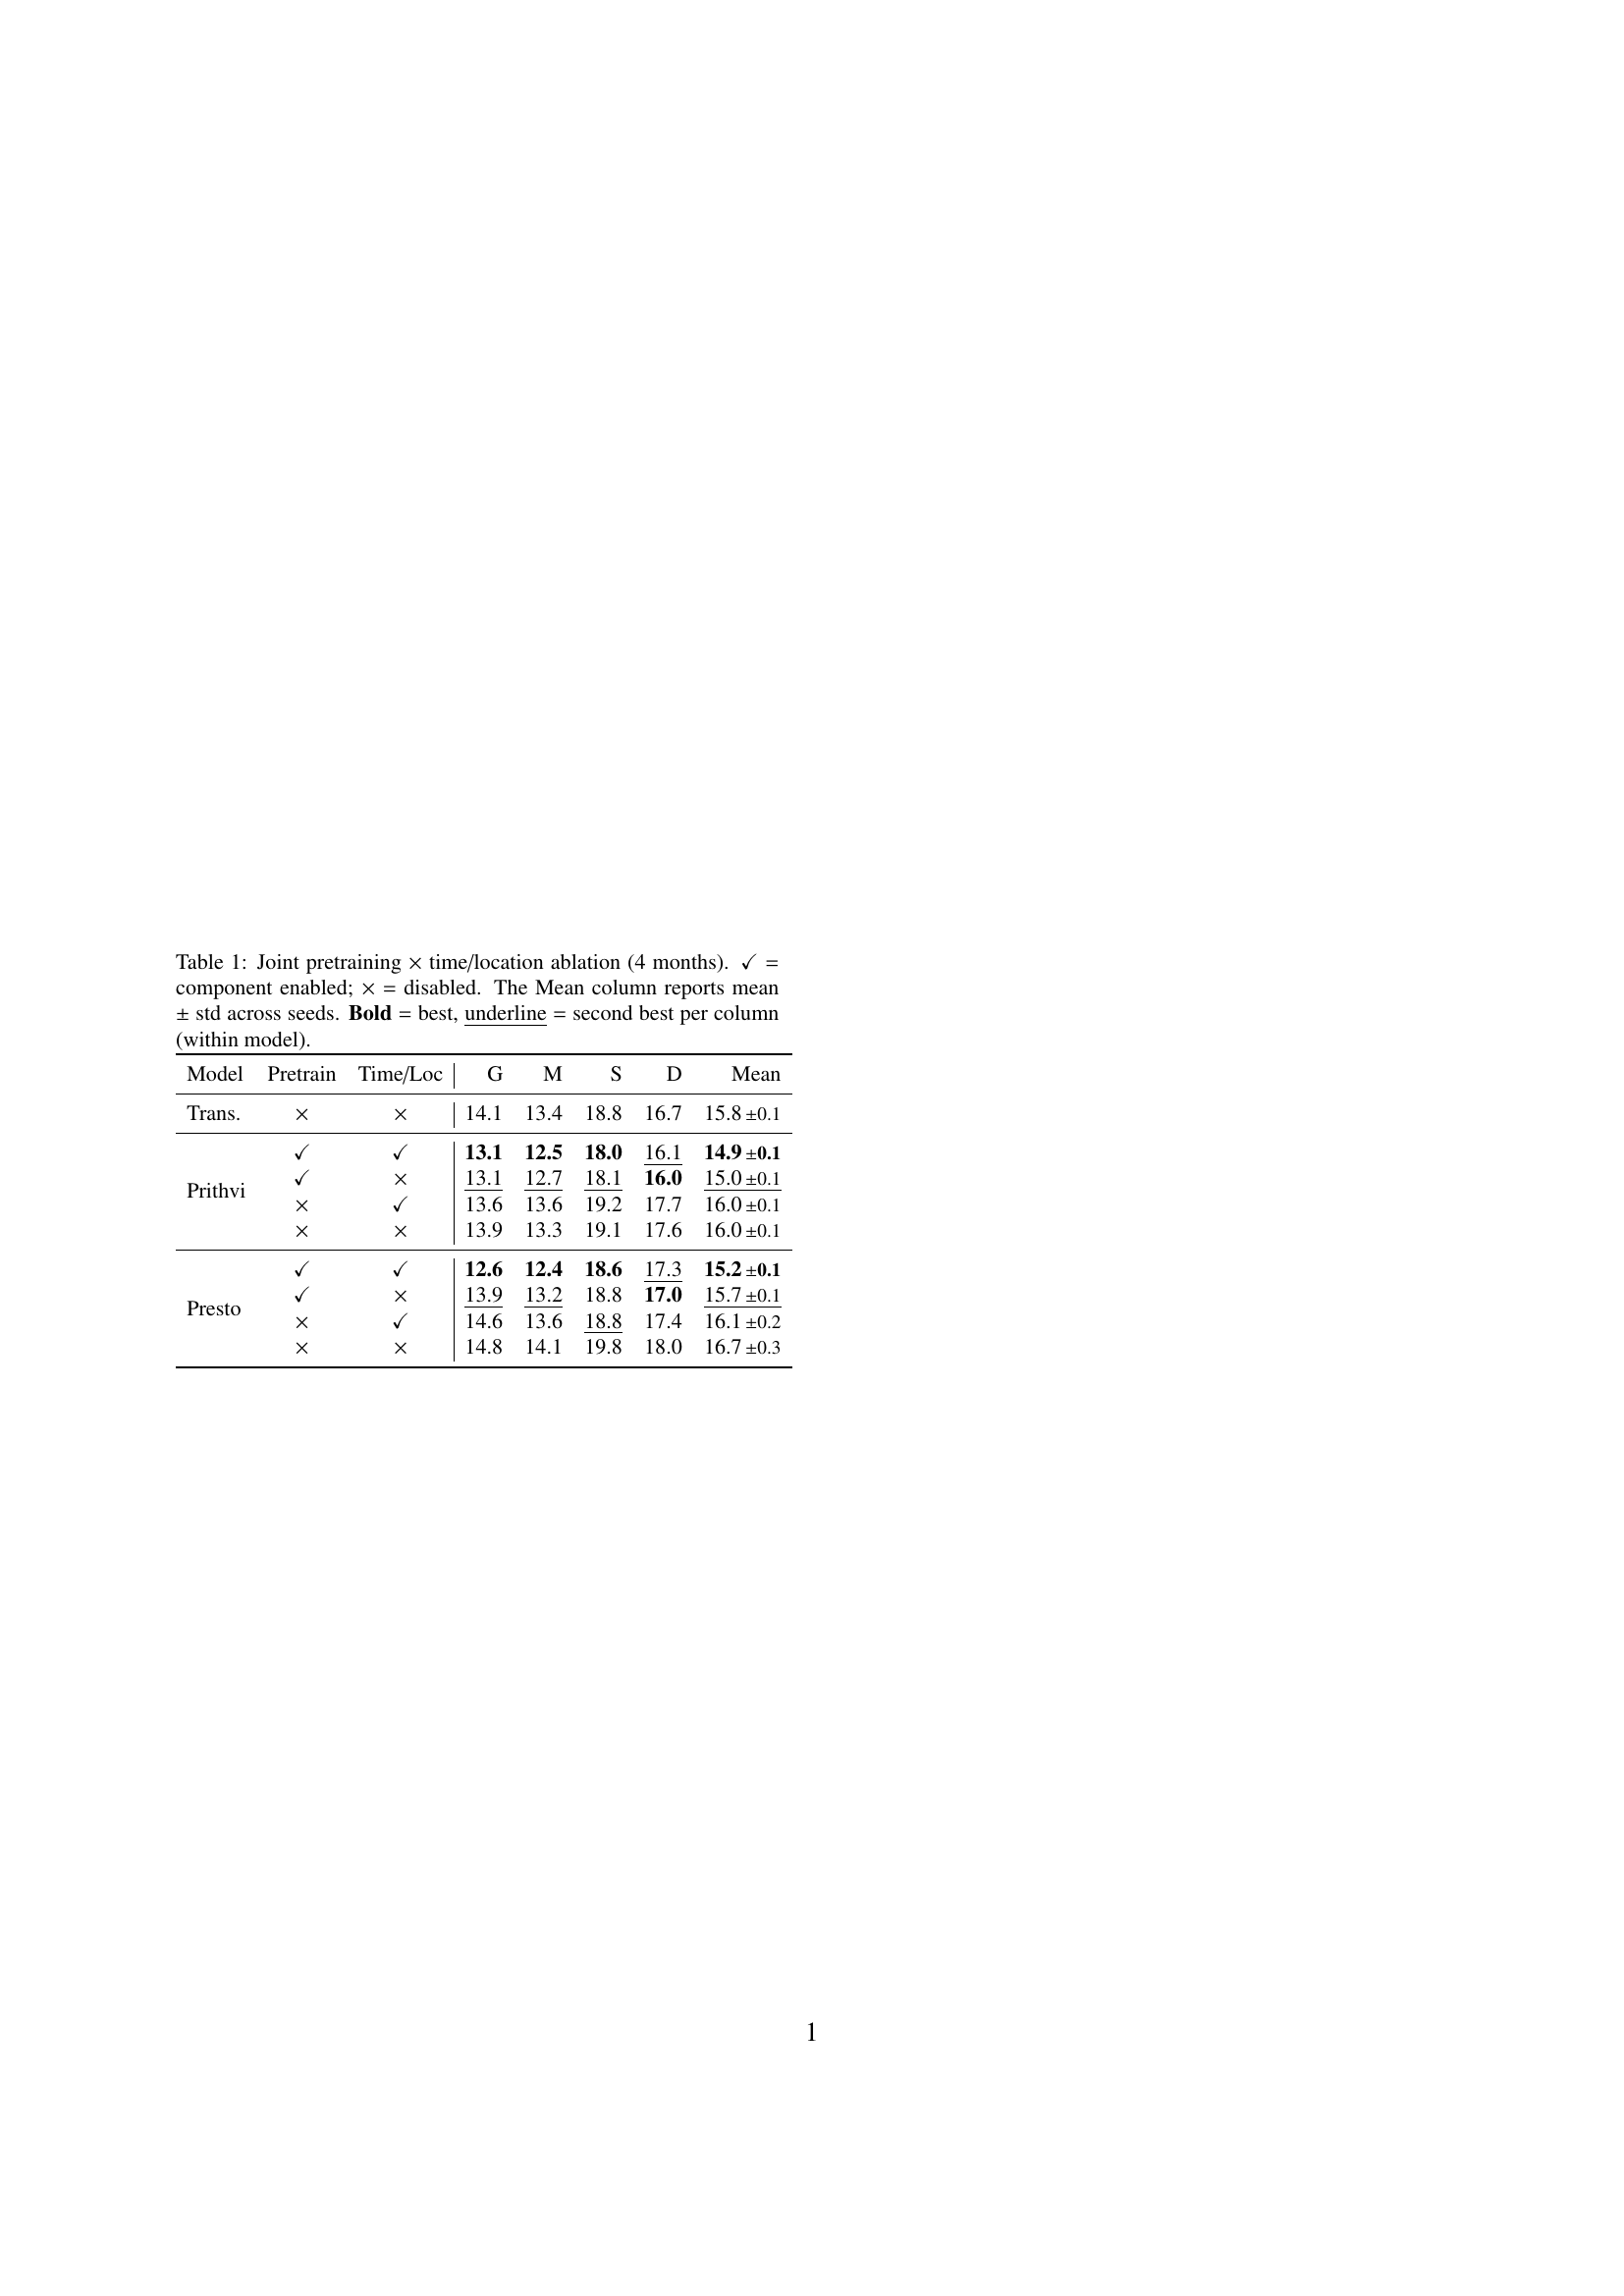


Saved: paper_latex/Tables/ablation.tex


In [10]:
# Combined pretraining x time/location ablation (per-seed mean ± std on Mean col)
ablation_variants = [
    # (display_name, key, has_pretrain, has_timeloc)
    ("Trans.",   "transformer_1d_paper_nl3_1.0_test",                    False, False),

    ("Prithvi",  "prithvi_final_100m_crop32_1.0_test",                True,  True),
    ("Prithvi",  "prithvi_final_100m_crop32_notimeloc_1.0_test",      True,  False),
    ("Prithvi",  "prithvi_nopretrain_100m_crop32_1.0_test",           False, True),
    ("Prithvi",  "prithvi_nopretrain_100m_crop32_notimeloc_1.0_test", False, False),

    ("Presto",   "presto_1.0_test",                                   True,  True),
    ("Presto",   "presto_notimeloc_1.0_test",                         True,  False),
    ("Presto",   "presto_nopretrain_1.0_test",                        False, True),
    ("Presto",   "presto_notimeloc_nopretrain_1.0_test",              False, False),
]

def _per_seed_stats(per_seed_dict, key):
    """For a given method key, return list of dicts {G, M, S, D, Mean} — one per seed CSV."""
    seed_dfs = per_seed_dict.get(key, [])
    out = []
    for sdf in seed_dfs:
        tile_info = sdf[["HLStile", "SiteID", "years"]].drop_duplicates().values
        per_date = {d: [] for d in DATE_NAMES}
        for tile, sid, yr in tile_info:
            df_t = sdf[(sdf["HLStile"] == tile) & (sdf["SiteID"] == sid) & (sdf["years"] == yr)]
            for d_name, d_short in zip(DATE_NAMES, DATE_SHORT):
                per_date[d_name].append(np.mean(np.abs(
                    df_t[f"{d_short}_pred_DOY"] - df_t[f"{d_short}_truth_DOY"])))
        sm = {d: np.mean(per_date[d]) for d in DATE_NAMES}
        sm["Mean"] = np.mean([sm[d] for d in DATE_NAMES])
        out.append(sm)
    return out


def _agg(samples):
    """Return dict with mean for each date column and (mean, std) for Mean."""
    if not samples:
        return None
    agg = {d: float(np.mean([s[d] for s in samples])) for d in DATE_NAMES}
    means = np.array([s["Mean"] for s in samples])
    agg["Mean"] = float(means.mean())
    agg["Mean_std"] = float(means.std(ddof=1)) if len(means) > 1 else 0.0
    return agg


def _fmt_mean_std(m, sd):
    return f"{m:.1f}{{\\scriptsize\\,$\\pm${sd:.1f}}}"


per_seed4 = all_results_per_seed.get(4, {})

rows_data = []
for model_name, key, has_pretrain, has_timeloc in ablation_variants:
    samples = _per_seed_stats(per_seed4, key)
    agg = _agg(samples)
    row = {"Model": model_name, "Pretrain": has_pretrain, "Time/Loc": has_timeloc}
    for col in DATE_NAMES + ["Mean"]:
        row[col] = float("nan") if agg is None else agg[col]
    row["Mean_std"] = 0.0 if agg is None else agg["Mean_std"]
    rows_data.append(row)

# Group by display model
model_order = []
model_rows = {}
for i, row in enumerate(rows_data):
    m = row["Model"]
    if m not in model_rows:
        model_rows[m] = []
        model_order.append(m)
    model_rows[m].append(i)

# Best/second per col within each model (skip single-row baselines)
date_cols = DATE_NAMES + ["Mean"]
fmt_info = {}
for m, indices in model_rows.items():
    if len(indices) < 2:
        continue
    for col in date_cols:
        vals = [(i, rows_data[i][col]) for i in indices if not np.isnan(rows_data[i][col])]
        vals.sort(key=lambda x: x[1])
        if len(vals) >= 1: fmt_info[(vals[0][0], col)] = "best"
        if len(vals) >= 2: fmt_info[(vals[1][0], col)] = "second"

L = []
L.append(r"\begin{table}[!t]")
L.append(r"\centering")
L.append(r"\footnotesize")
L.append(r"\setlength{\tabcolsep}{4pt}")
L.append(r"\caption{Joint pretraining $\times$ time/location ablation (4 months). \checkmark\ = component enabled; $\times$ = disabled. The Mean column reports mean $\pm$ std across seeds. \textbf{Bold} = best, \underline{underline} = second best per column (within model).}")
L.append(r"\label{tab:ablation}")
L.append(r"\begin{tabular}{lcc|rrrrr}")
L.append(r"\toprule")
L.append(r"Model & Pretrain & Time/Loc & G & M & S & D & Mean \\")
L.append(r"\midrule")

first_group = True
for model_name in model_order:
    indices = model_rows[model_name]
    n = len(indices)
    if not first_group:
        L.append(r"\midrule")
    first_group = False
    for j, idx in enumerate(indices):
        row = rows_data[idx]
        if j == 0:
            model_cell = r"\multirow{" + str(n) + r"}{*}{" + model_name + r"}"
        else:
            model_cell = ""
        cells = [
            model_cell,
            r"\checkmark" if row["Pretrain"] else r"$\times$",
            r"\checkmark" if row["Time/Loc"] else r"$\times$",
        ]
        for col in date_cols:
            v = row[col]
            if np.isnan(v):
                cells.append("---")
                continue
            if col == "Mean":
                txt = _fmt_mean_std(v, row["Mean_std"])
            else:
                txt = f"{v:.1f}"
            fmt = fmt_info.get((idx, col), "")
            if fmt == "best":
                cells.append(r"\textbf{" + txt + "}")
            elif fmt == "second":
                cells.append(r"\underline{" + txt + "}")
            else:
                cells.append(txt)
        L.append(" & ".join(cells) + r" \\")
L.append(r"\bottomrule")
L.append(r"\end{tabular}")
L.append(r"\end{table}")
latex_str = "\n".join(L)

render_latex_preview(latex_str)

with open("paper_latex/Tables/ablation.tex", "w") as f:
    f.write(latex_str)
print("\nSaved: paper_latex/Tables/ablation.tex")


## 6. Presto: Regularization Ablation

Effect of enabling/disabling location dropout ($p_{\text{loc}} > 0$) and weight dropout on Presto, across all input-month subsets. Missing runs are shown as ---.

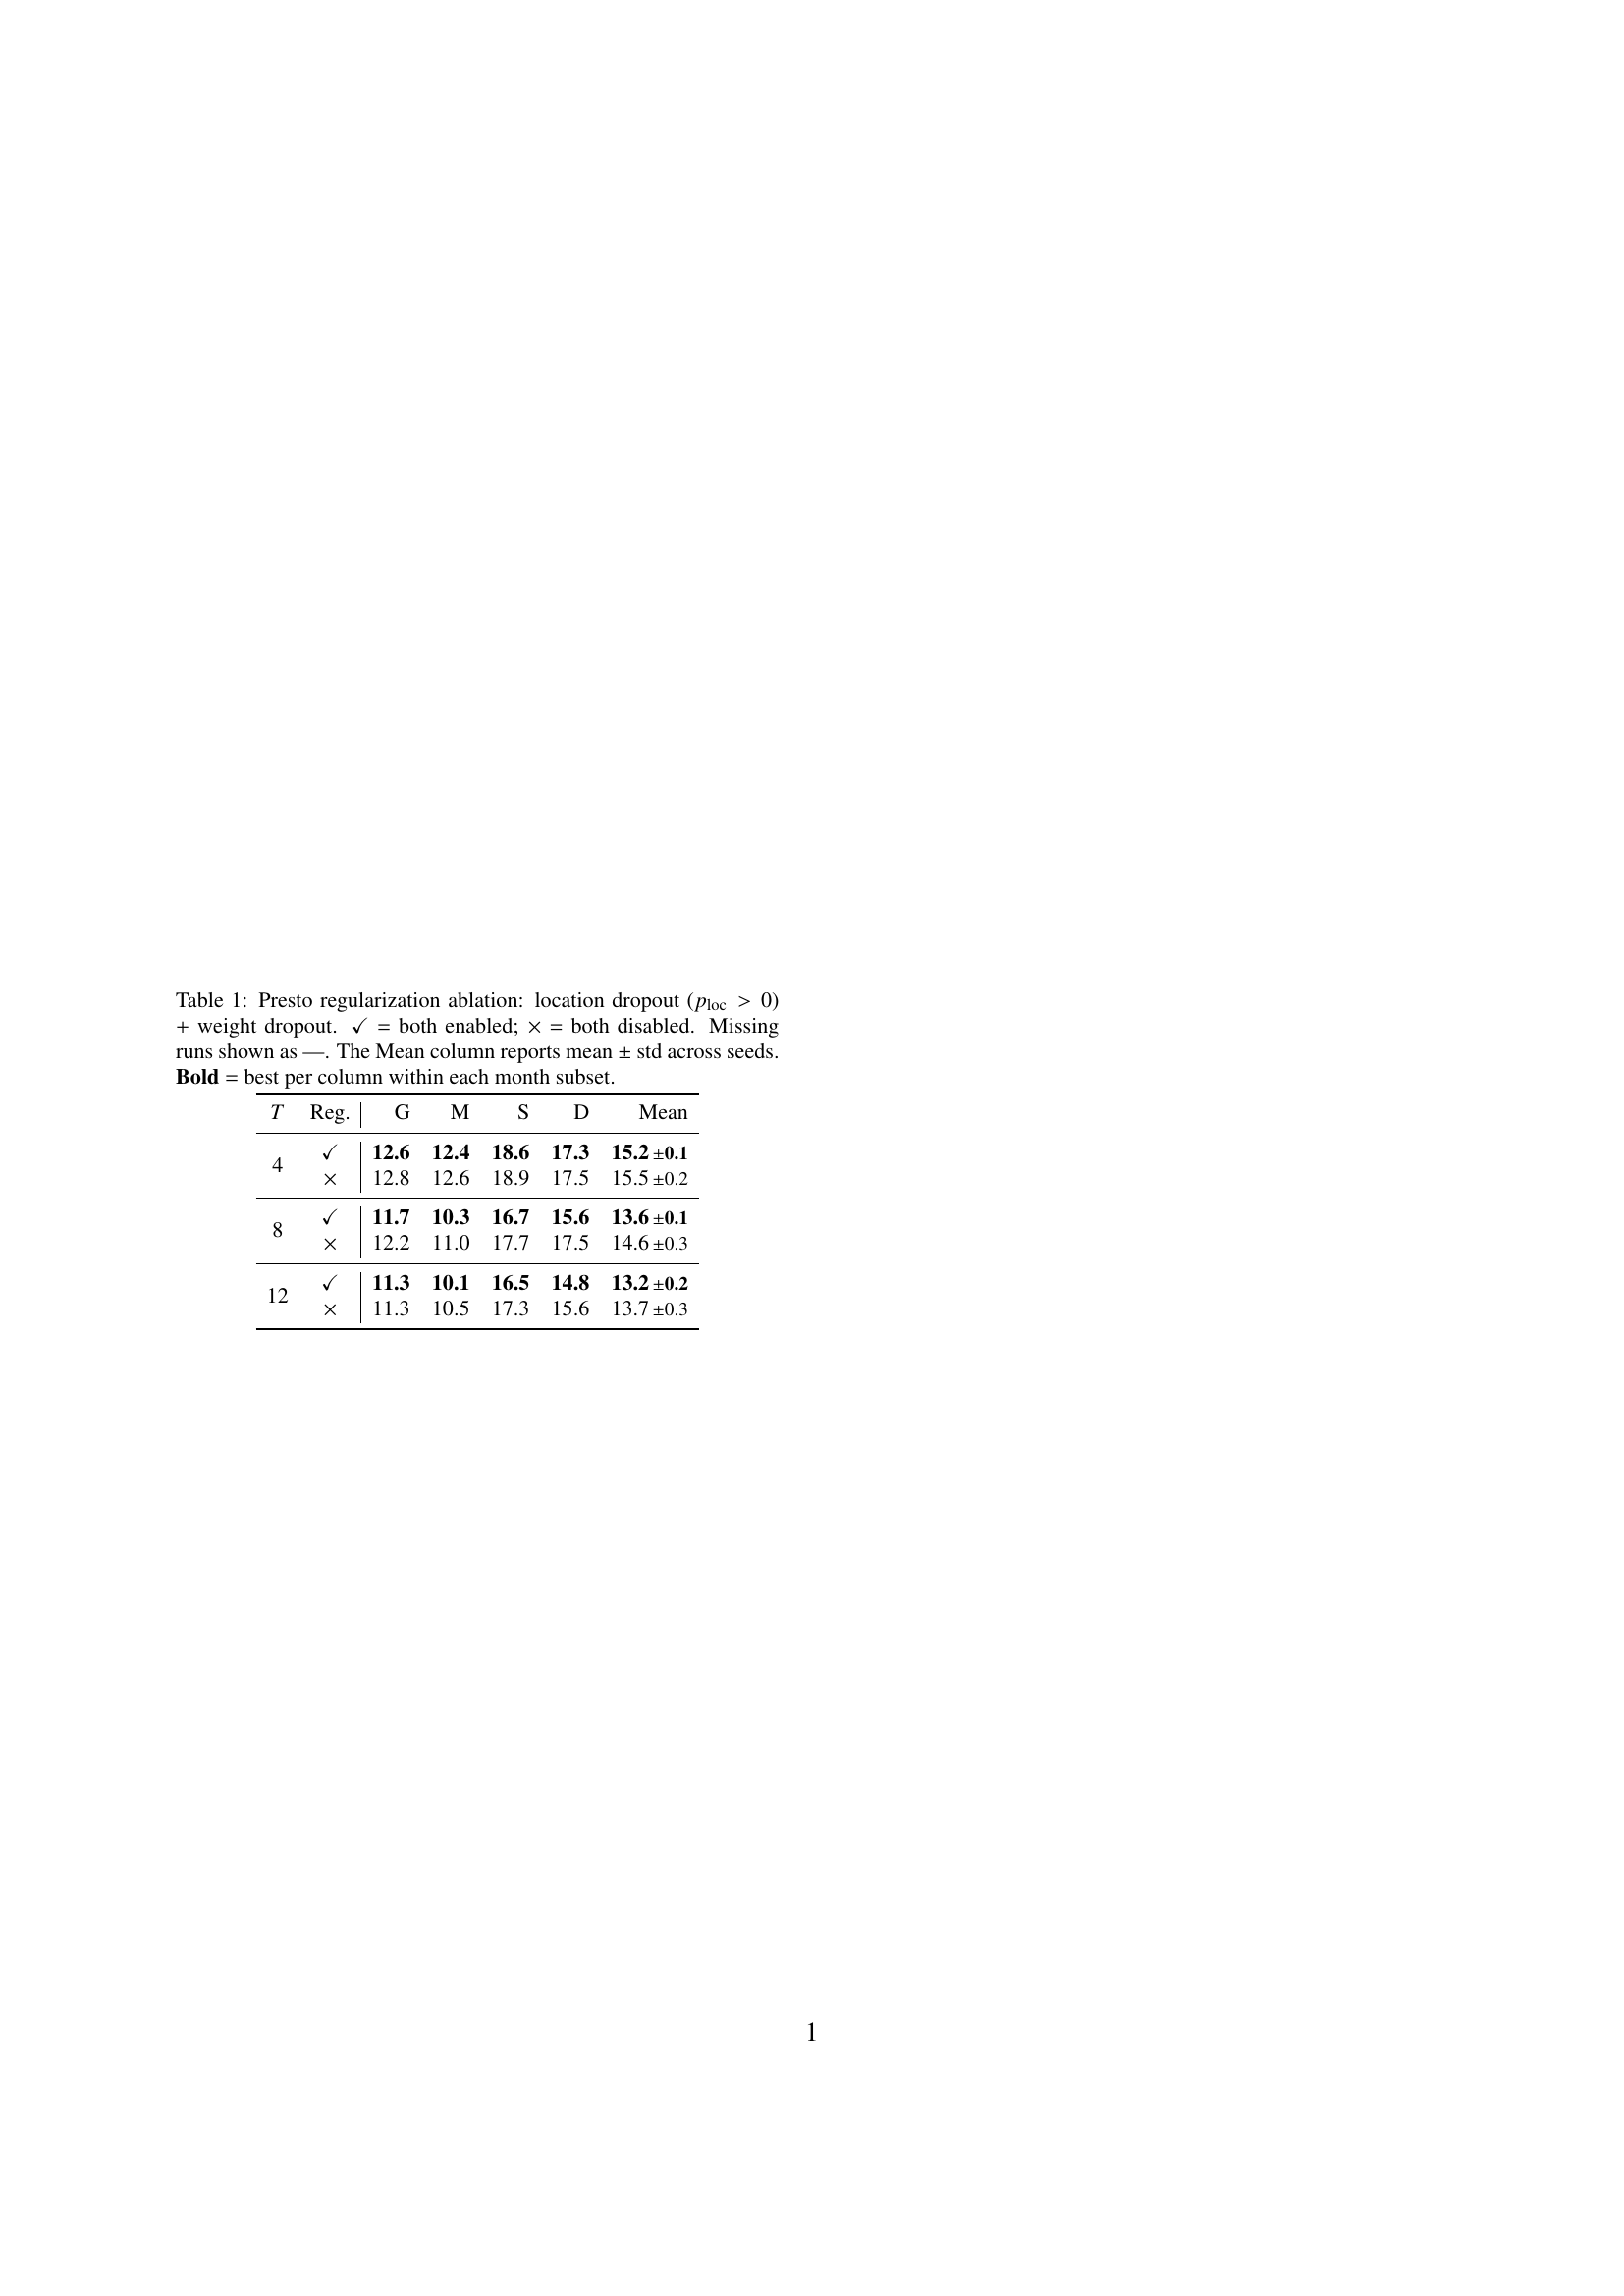


Saved: paper_latex/Tables/presto_locdrop_ablation.tex


In [11]:
# Loc-drop + weight-dropout ablation (Presto only) across subsets, with mean ± std on Mean col
model_variants = [
    # (has_reg, key)
    (True,  "presto_1.0_test"),
    (False, "presto_nolocdrop_nodropout_1.0_test"),
]
month_subsets = sorted(MONTH_SUBSETS.keys())
date_cols = DATE_NAMES + ["Mean"]


def _per_seed_stats(per_seed_dict, key):
    seed_dfs = per_seed_dict.get(key, [])
    out = []
    for sdf in seed_dfs:
        tile_info = sdf[["HLStile", "SiteID", "years"]].drop_duplicates().values
        per_date = {d: [] for d in DATE_NAMES}
        for tile, sid, yr in tile_info:
            df_t = sdf[(sdf["HLStile"] == tile) & (sdf["SiteID"] == sid) & (sdf["years"] == yr)]
            for d_name, d_short in zip(DATE_NAMES, DATE_SHORT):
                per_date[d_name].append(np.mean(np.abs(
                    df_t[f"{d_short}_pred_DOY"] - df_t[f"{d_short}_truth_DOY"])))
        sm = {d: np.mean(per_date[d]) for d in DATE_NAMES}
        sm["Mean"] = np.mean([sm[d] for d in DATE_NAMES])
        out.append(sm)
    return out


def _agg(samples):
    if not samples:
        return None
    agg = {d: float(np.mean([s[d] for s in samples])) for d in DATE_NAMES}
    means = np.array([s["Mean"] for s in samples])
    agg["Mean"] = float(means.mean())
    agg["Mean_std"] = float(means.std(ddof=1)) if len(means) > 1 else 0.0
    return agg


def _fmt_mean_std(m, sd):
    return f"{m:.1f}{{\\scriptsize\\,$\\pm${sd:.1f}}}"


rows_data = []
for nm in month_subsets:
    per_seed = all_results_per_seed.get(nm, {})
    for has_reg, key in model_variants:
        samples = _per_seed_stats(per_seed, key)
        agg = _agg(samples)
        row = {"Months": nm, "Reg": has_reg}
        for col in date_cols:
            row[col] = float("nan") if agg is None else agg[col]
        row["Mean_std"] = 0.0 if agg is None else agg["Mean_std"]
        rows_data.append(row)

fmt_info = {}
for nm in month_subsets:
    idxs = [i for i, r in enumerate(rows_data) if r["Months"] == nm]
    for col in date_cols:
        vals = [(i, rows_data[i][col]) for i in idxs if not np.isnan(rows_data[i][col])]
        vals.sort(key=lambda x: x[1])
        if len(vals) >= 1: fmt_info[(vals[0][0], col)] = "best"

L = []
L.append(r"\begin{table}[!t]")
L.append(r"\centering")
L.append(r"\footnotesize")
L.append(r"\setlength{\tabcolsep}{4pt}")
L.append(r"\caption{Presto regularization ablation: location dropout ($p_{\text{loc}}>0$) + weight dropout. \checkmark\ = both enabled; $\times$ = both disabled. Missing runs shown as ---. The Mean column reports mean $\pm$ std across seeds. \textbf{Bold} = best per column within each month subset.}")
L.append(r"\label{tab:presto_locdrop_ablation}")
L.append(r"\begin{tabular}{cc|rrrrr}")
L.append(r"\toprule")
L.append(r"$T$ & Reg. & G & M & S & D & Mean \\")
L.append(r"\midrule")

first_month = True
for nm in month_subsets:
    if not first_month:
        L.append(r"\midrule")
    first_month = False
    month_rows = [(i, r) for i, r in enumerate(rows_data) if r["Months"] == nm]
    for j, (i, row) in enumerate(month_rows):
        t_cell = r"\multirow{" + str(len(month_rows)) + r"}{*}{" + str(nm) + "}" if j == 0 else ""
        cells = [t_cell, r"\checkmark" if row["Reg"] else r"$\times$"]
        for col in date_cols:
            v = row[col]
            if np.isnan(v):
                cells.append("---")
                continue
            if col == "Mean":
                txt = _fmt_mean_std(v, row["Mean_std"])
            else:
                txt = f"{v:.1f}"
            fmt = fmt_info.get((i, col), "")
            if fmt == "best":
                cells.append(r"\textbf{" + txt + "}")
            else:
                cells.append(txt)
        L.append(" & ".join(cells) + r" \\")

L.append(r"\bottomrule")
L.append(r"\end{tabular}")
L.append(r"\end{table}")
latex_str = "\n".join(L)

render_latex_preview(latex_str)

with open("paper_latex/Tables/presto_locdrop_ablation.tex", "w") as f:
    f.write(latex_str)
print("\nSaved: paper_latex/Tables/presto_locdrop_ablation.tex")


## 7. Prithvi: Concat Ablation

Effect of concatenating the raw 6-band input with upscaled ViT features before the fusion head, on the 4-month subset (100M, crop32).

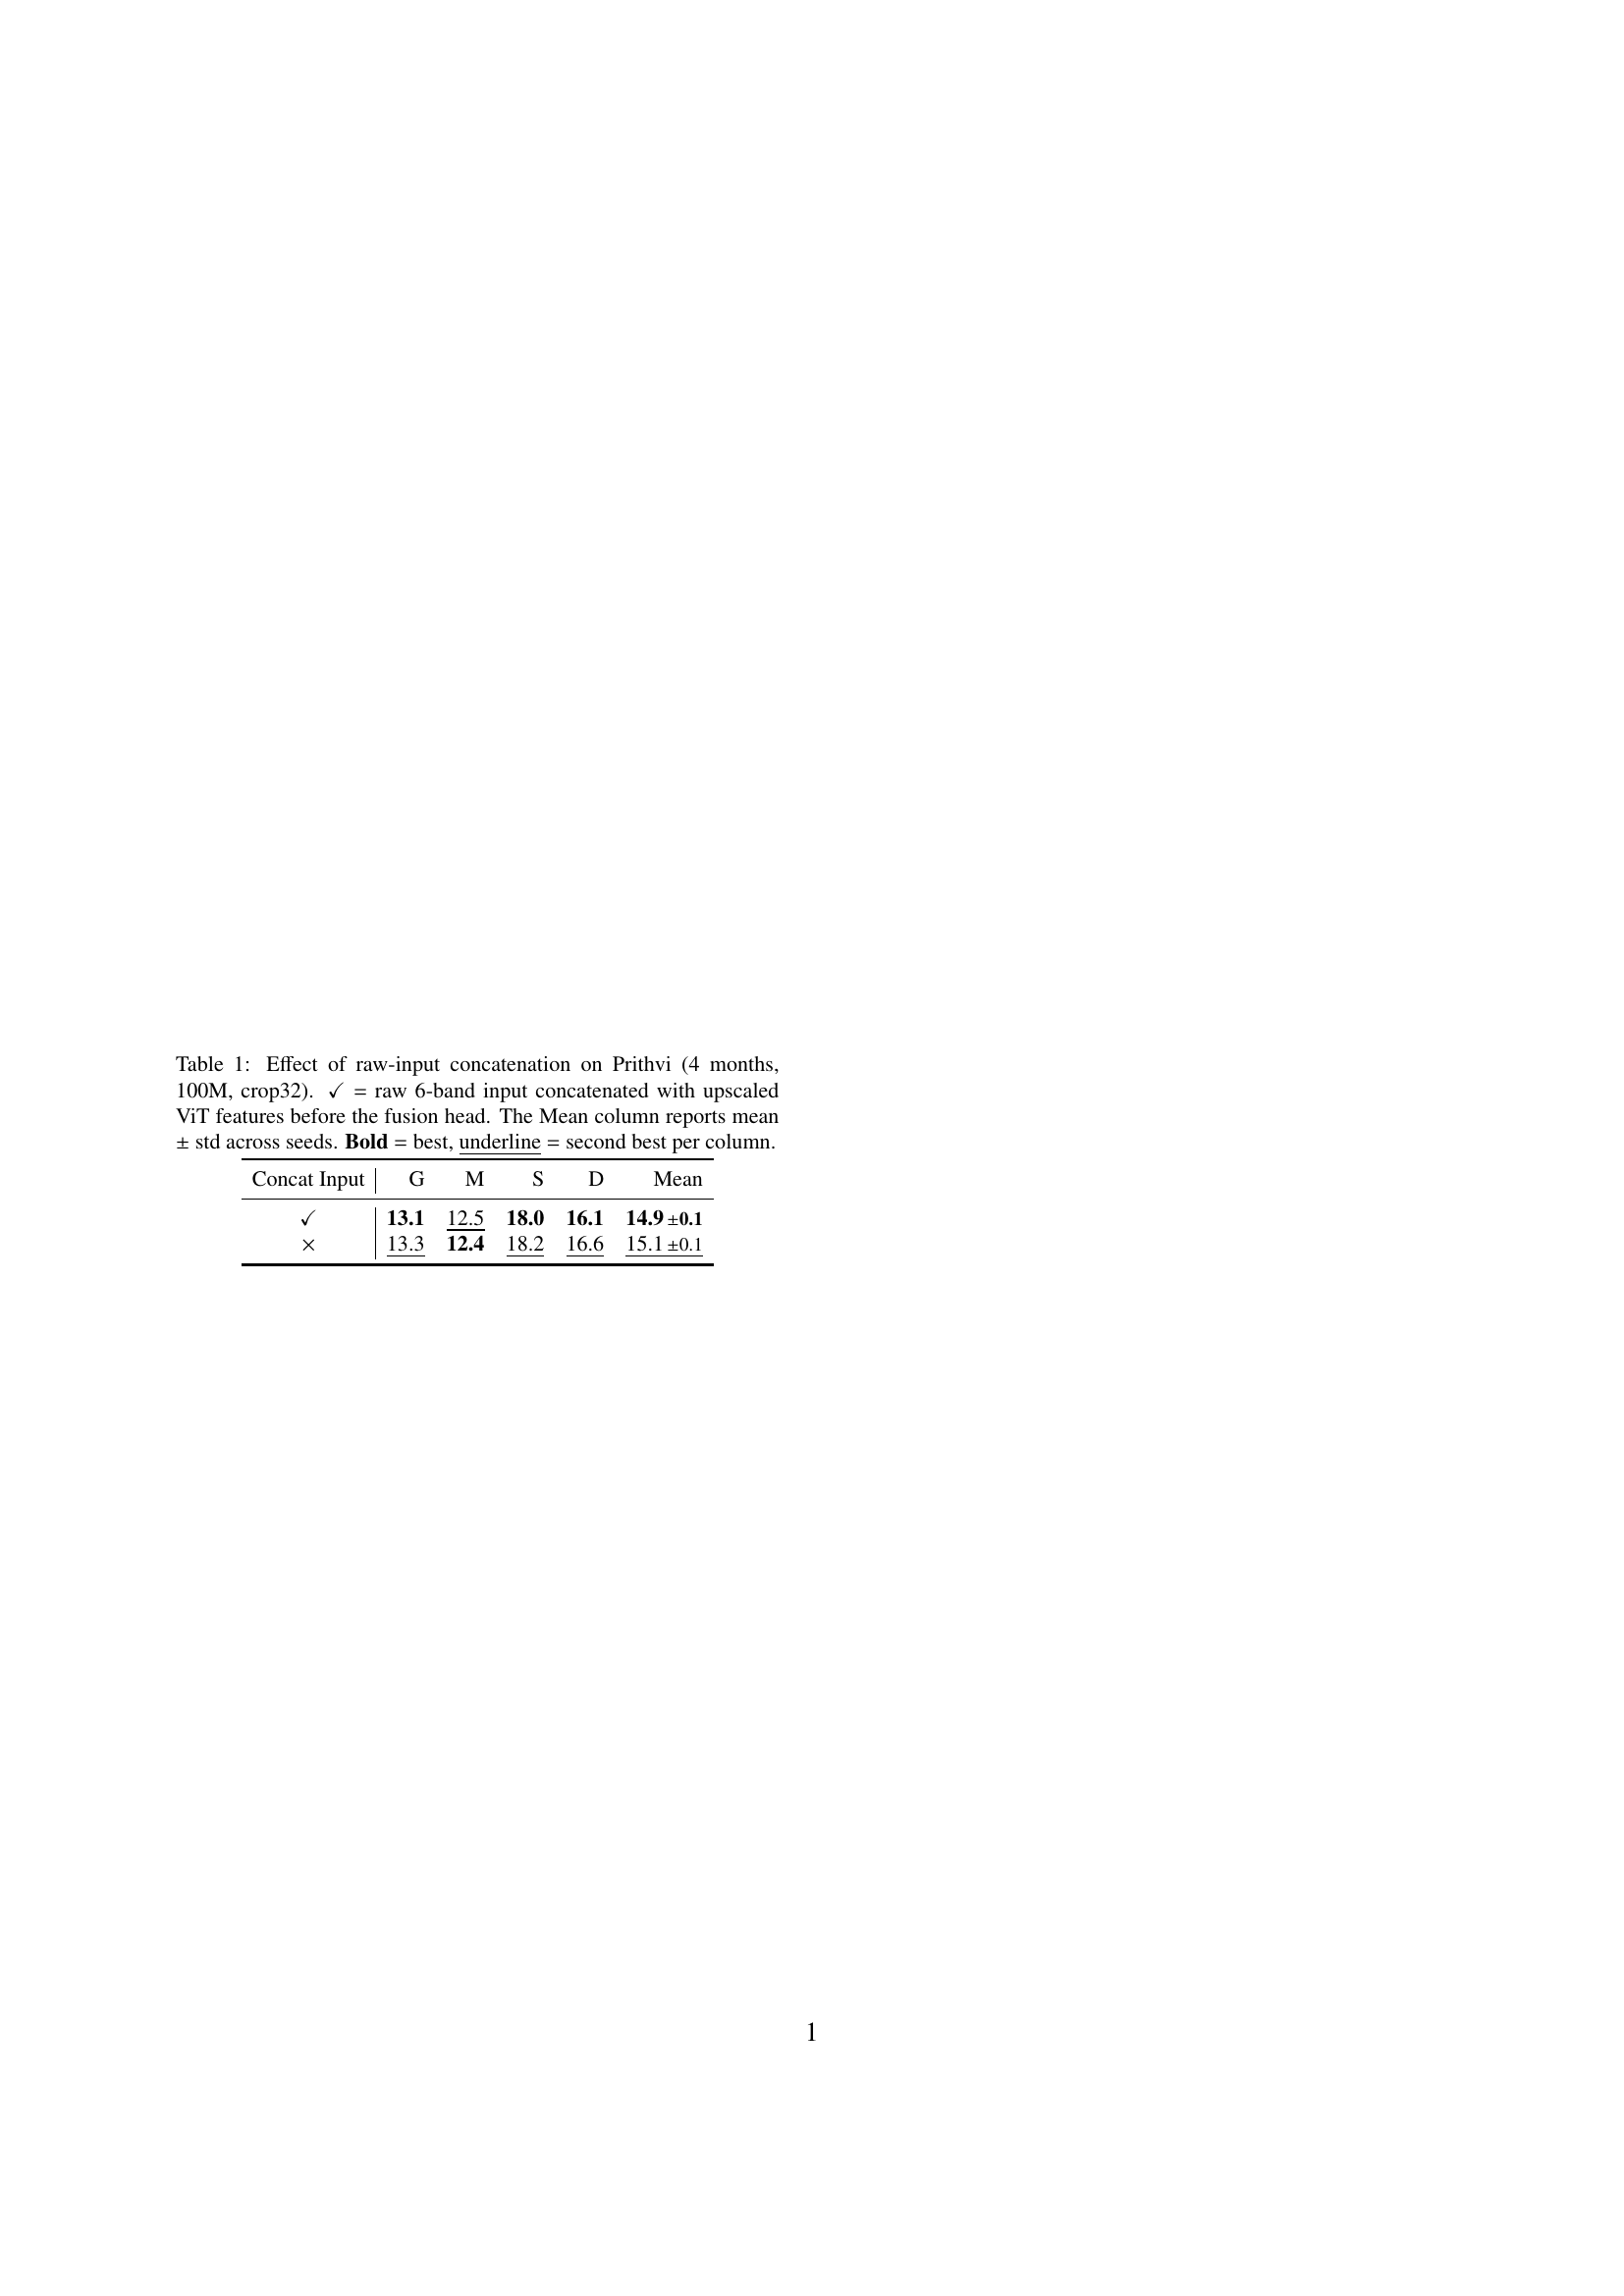


Saved: paper_latex/Tables/prithvi_concat_ablation.tex


In [12]:
# Prithvi concat ablation: concat (default) vs. no-concat at 4 months, 100M, crop32
from collections import OrderedDict
prithvi_concat_variants = OrderedDict([
    (True,  "prithvi_final_100m_crop32_1.0_test"),
    (False, "prithvi_final_100m_crop32_noconcat_1.0_test"),
])


def _per_seed_stats(per_seed_dict, key):
    """For a given method key, return list of dicts {G, M, S, D, Mean} — one per seed CSV."""
    seed_dfs = per_seed_dict.get(key, [])
    out = []
    for sdf in seed_dfs:
        tile_info = sdf[["HLStile", "SiteID", "years"]].drop_duplicates().values
        per_date = {d: [] for d in DATE_NAMES}
        for tile, sid, yr in tile_info:
            df_t = sdf[(sdf["HLStile"] == tile) & (sdf["SiteID"] == sid) & (sdf["years"] == yr)]
            for d_name, d_short in zip(DATE_NAMES, DATE_SHORT):
                per_date[d_name].append(np.mean(np.abs(
                    df_t[f"{d_short}_pred_DOY"] - df_t[f"{d_short}_truth_DOY"])))
        sm = {d: np.mean(per_date[d]) for d in DATE_NAMES}
        sm["Mean"] = np.mean([sm[d] for d in DATE_NAMES])
        out.append(sm)
    return out


def _agg(samples):
    if not samples:
        return None
    agg = {d: float(np.mean([s[d] for s in samples])) for d in DATE_NAMES}
    means = np.array([s["Mean"] for s in samples])
    agg["Mean"] = float(means.mean())
    agg["Mean_std"] = float(means.std(ddof=1)) if len(means) > 1 else 0.0
    return agg


def _fmt_mean_std(m, sd):
    return f"{m:.1f}{{\\scriptsize\\,$\\pm${sd:.1f}}}"


per_seed4 = all_results_per_seed.get(4, {})
rows = []
for has_concat, key in prithvi_concat_variants.items():
    samples = _per_seed_stats(per_seed4, key)
    agg = _agg(samples)
    row = {"Concat": has_concat}
    for col in DATE_NAMES + ["Mean"]:
        row[col] = float("nan") if agg is None else agg[col]
    row["Mean_std"] = 0.0 if agg is None else agg["Mean_std"]
    rows.append(row)

cols = DATE_NAMES + ["Mean"]
fmt_info = {}
for col in cols:
    vals = [(i, rows[i][col]) for i in range(len(rows)) if not np.isnan(rows[i][col])]
    vals.sort(key=lambda x: x[1])
    if len(vals) >= 1: fmt_info[(vals[0][0], col)] = "best"
    if len(vals) >= 2: fmt_info[(vals[1][0], col)] = "second"

short_cols = {"Greenup": "G", "Maturity": "M", "Senescence": "S", "Dormancy": "D", "Mean": "Mean"}
mark = {True: r"\checkmark", False: r"$\times$"}

L = []
L.append(r"\begin{table}[!t]")
L.append(r"\centering")
L.append(r"\footnotesize")
L.append(r"\setlength{\tabcolsep}{4pt}")
L.append(r"\caption{Effect of raw-input concatenation on Prithvi (4 months, 100M, crop32). \checkmark\ = raw 6-band input concatenated with upscaled ViT features before the fusion head. The Mean column reports mean $\pm$ std across seeds. \textbf{Bold} = best, \underline{underline} = second best per column.}")
L.append(r"\label{tab:prithvi_concat_ablation}")
L.append(r"\begin{tabular}{c|" + "r"*len(cols) + "}")
L.append(r"\toprule")
L.append("Concat Input & " + " & ".join(short_cols[c] for c in cols) + r" \\")
L.append(r"\midrule")
for i, row in enumerate(rows):
    cells = [mark[row["Concat"]]]
    for col in cols:
        v = row[col]
        if np.isnan(v):
            cells.append("---")
            continue
        if col == "Mean":
            txt = _fmt_mean_std(v, row["Mean_std"])
        else:
            txt = f"{v:.1f}"
        fmt = fmt_info.get((i, col), "")
        if fmt == "best":
            cells.append(r"\textbf{" + txt + "}")
        elif fmt == "second":
            cells.append(r"\underline{" + txt + "}")
        else:
            cells.append(txt)
    L.append(" & ".join(cells) + r" \\")
L.append(r"\bottomrule")
L.append(r"\end{tabular}")
L.append(r"\end{table}")
latex_str = "\n".join(L)

render_latex_preview(latex_str)

with open("paper_latex/Tables/prithvi_concat_ablation.tex", "w") as f:
    f.write(latex_str)
print("\nSaved: paper_latex/Tables/prithvi_concat_ablation.tex")

## 8. Prithvi: Model Size Comparison

Comparing Prithvi backbone sizes (Tiny, 100M, 300M) at crop32 on the 4-month subset.

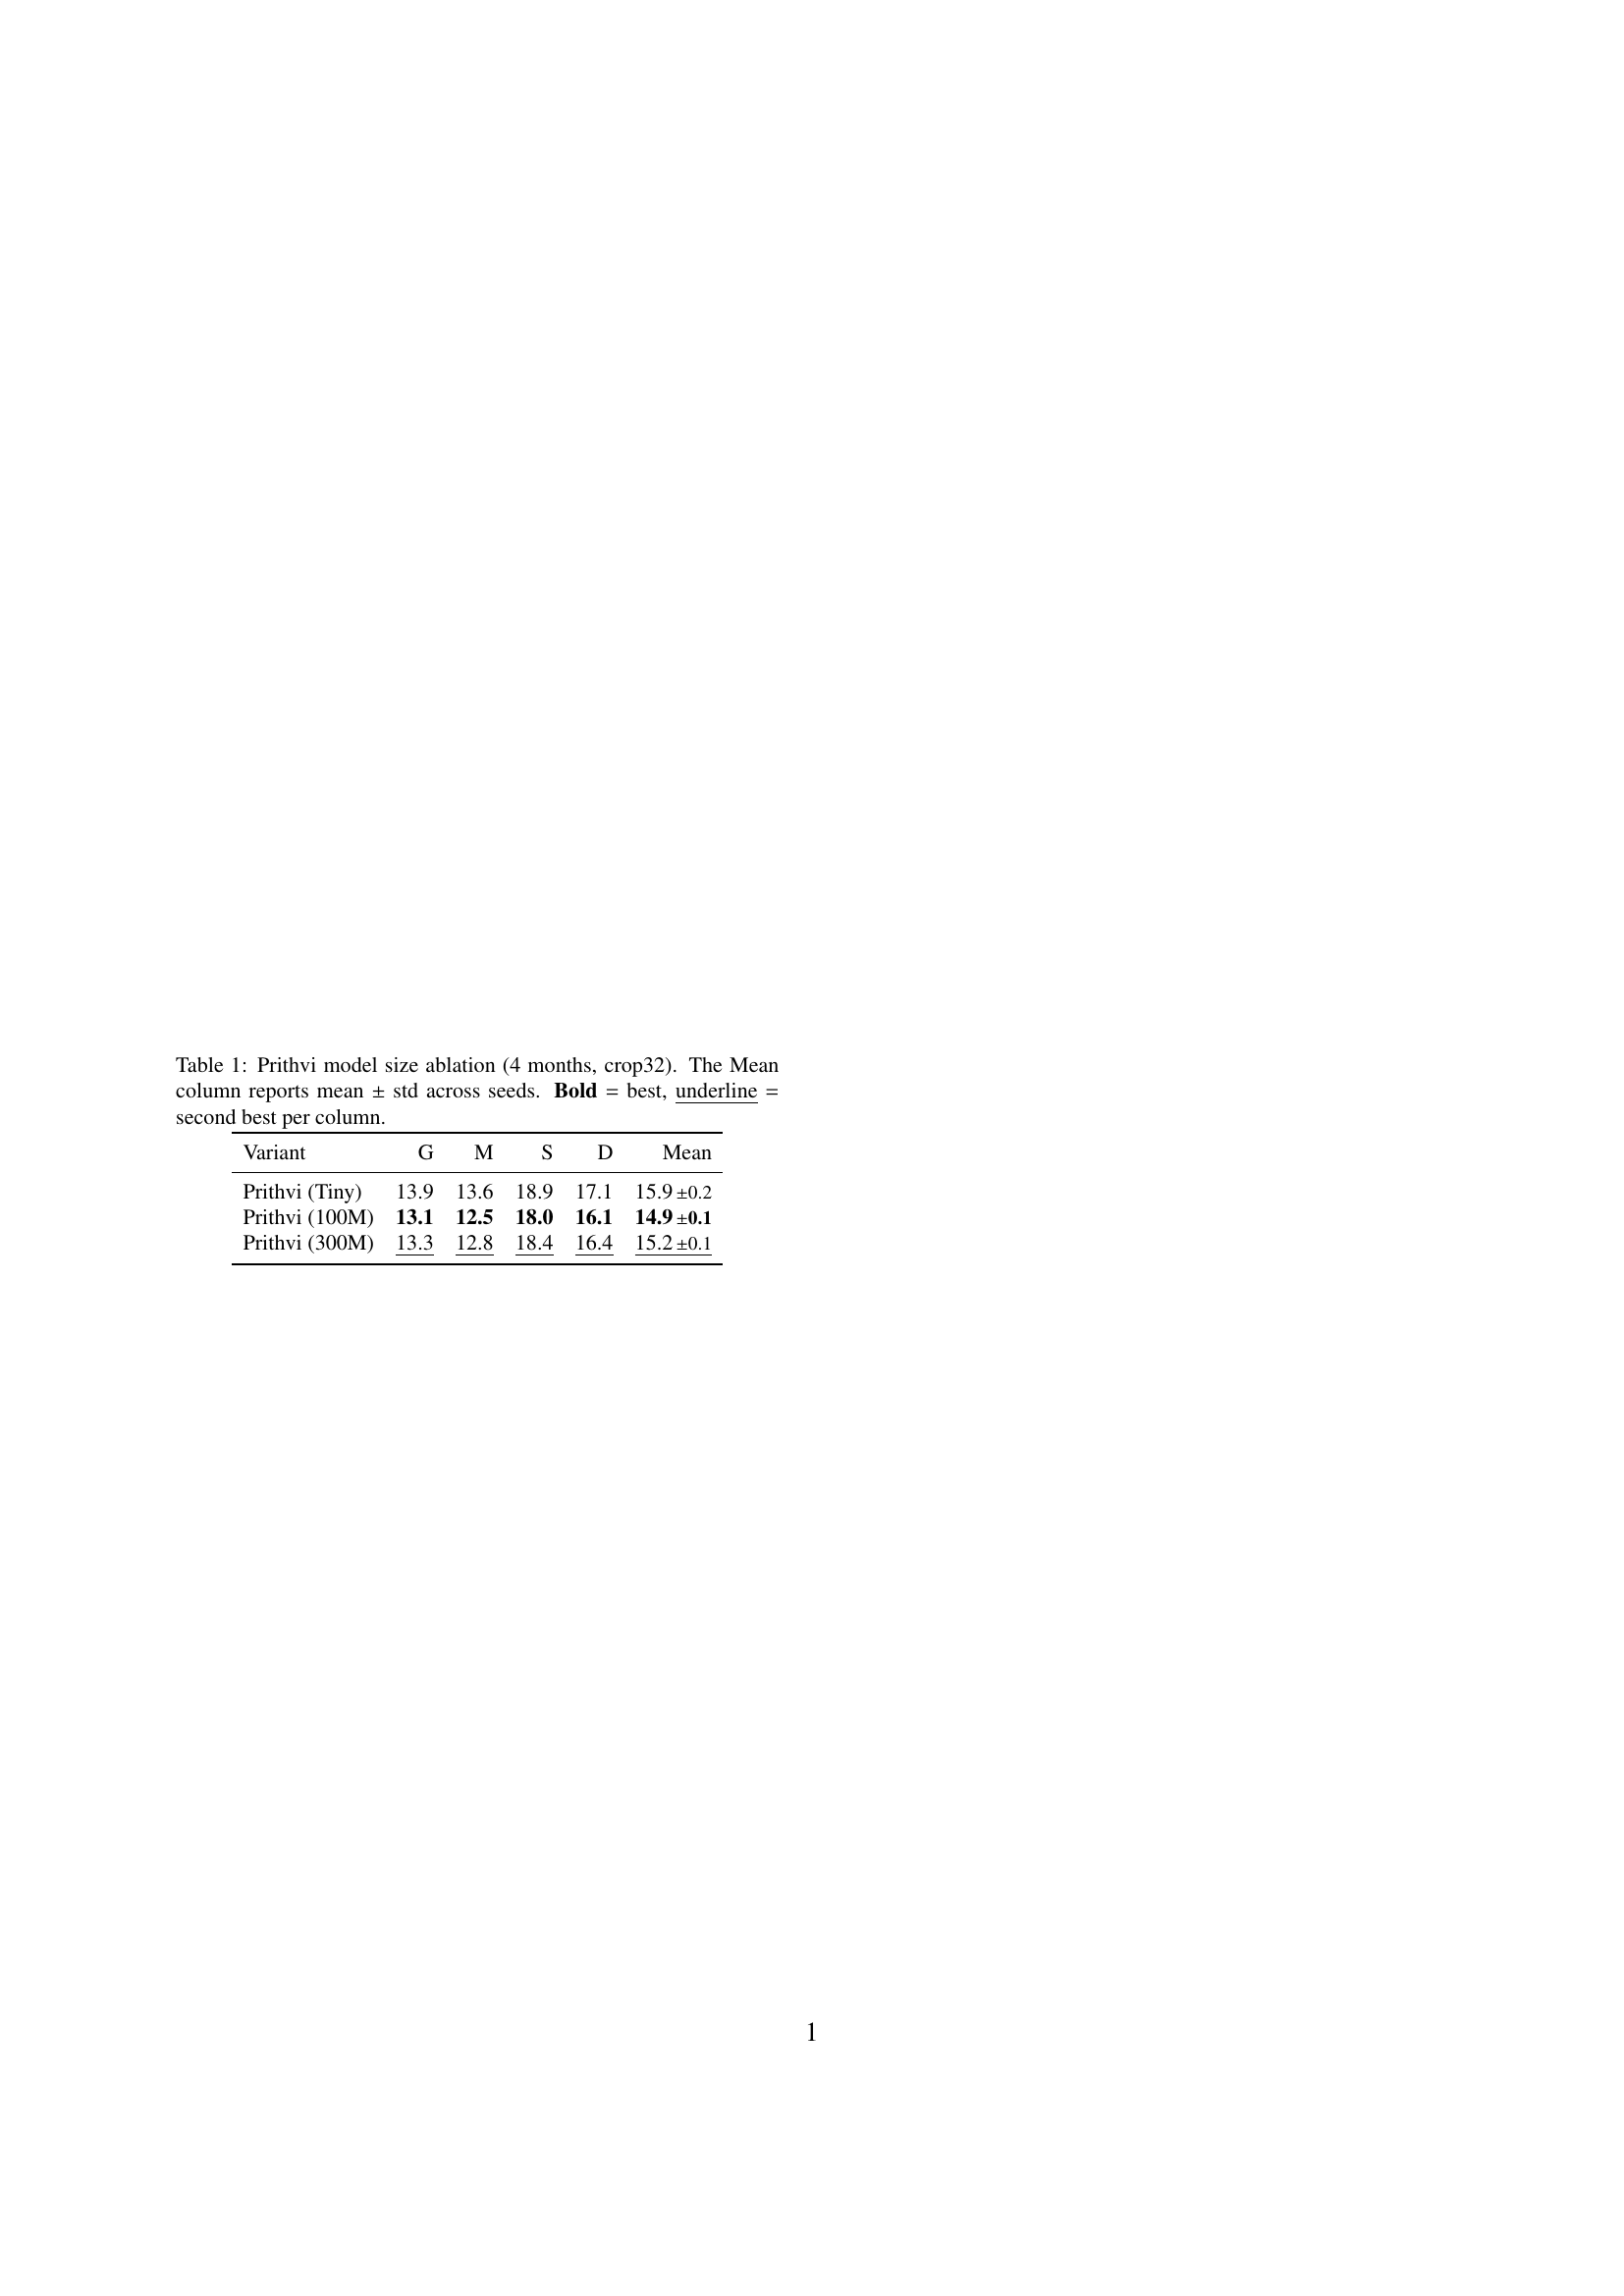


Saved: paper_latex/Tables/prithvi_size_ablation.tex


In [13]:
from collections import OrderedDict
prithvi_size_variants = OrderedDict([
    ("Prithvi (Tiny)",  "prithvi_final_tiny_crop32_1.0_test"),
    ("Prithvi (100M)",  "prithvi_final_100m_crop32_1.0_test"),
    ("Prithvi (300M)",  "prithvi_final_300m_crop32_1.0_test"),
])


def _per_seed_stats(per_seed_dict, key):
    """For a given method key, return list of dicts {G, M, S, D, Mean} — one per seed CSV."""
    seed_dfs = per_seed_dict.get(key, [])
    out = []
    for sdf in seed_dfs:
        tile_info = sdf[["HLStile", "SiteID", "years"]].drop_duplicates().values
        per_date = {d: [] for d in DATE_NAMES}
        for tile, sid, yr in tile_info:
            df_t = sdf[(sdf["HLStile"] == tile) & (sdf["SiteID"] == sid) & (sdf["years"] == yr)]
            for d_name, d_short in zip(DATE_NAMES, DATE_SHORT):
                per_date[d_name].append(np.mean(np.abs(
                    df_t[f"{d_short}_pred_DOY"] - df_t[f"{d_short}_truth_DOY"])))
        sm = {d: np.mean(per_date[d]) for d in DATE_NAMES}
        sm["Mean"] = np.mean([sm[d] for d in DATE_NAMES])
        out.append(sm)
    return out


def _agg(samples):
    """Return dict with mean for each date column and (mean, std) for Mean."""
    if not samples:
        return None
    agg = {d: float(np.mean([s[d] for s in samples])) for d in DATE_NAMES}
    means = np.array([s["Mean"] for s in samples])
    agg["Mean"] = float(means.mean())
    agg["Mean_std"] = float(means.std(ddof=1)) if len(means) > 1 else 0.0
    return agg


def _fmt_mean_std(m, sd):
    return f"{m:.1f}{{\\scriptsize\\,$\\pm${sd:.1f}}}"


per_seed4 = all_results_per_seed.get(4, {})
rows = []
for variant, key in prithvi_size_variants.items():
    samples = _per_seed_stats(per_seed4, key)
    agg = _agg(samples)
    row = {"Variant": variant}
    for col in DATE_NAMES + ["Mean"]:
        row[col] = float("nan") if agg is None else agg[col]
    row["Mean_std"] = 0.0 if agg is None else agg["Mean_std"]
    rows.append(row)

cols = DATE_NAMES + ["Mean"]
fmt_info = {}
for col in cols:
    vals = [(i, rows[i][col]) for i in range(len(rows)) if not np.isnan(rows[i][col])]
    vals.sort(key=lambda x: x[1])
    if len(vals) >= 1: fmt_info[(vals[0][0], col)] = "best"
    if len(vals) >= 2: fmt_info[(vals[1][0], col)] = "second"

short_cols = {"Greenup": "G", "Maturity": "M", "Senescence": "S", "Dormancy": "D", "Mean": "Mean"}

latex_lines = []
latex_lines.append(r"\begin{table}[!t]")
latex_lines.append(r"\centering")
latex_lines.append(r"\footnotesize")
latex_lines.append(r"\setlength{\tabcolsep}{4pt}")
latex_lines.append(r"\caption{Prithvi model size ablation (4 months, crop32). The Mean column reports mean $\pm$ std across seeds. \textbf{Bold} = best, \underline{underline} = second best per column.}")
latex_lines.append(r"\label{tab:prithvi_size_ablation}")
latex_lines.append(r"\begin{tabular}{l" + "r"*len(cols) + "}")
latex_lines.append(r"\toprule")
latex_lines.append("Variant & " + " & ".join(short_cols[c] for c in cols) + r" \\")
latex_lines.append(r"\midrule")
for i, row in enumerate(rows):
    cells = [row["Variant"]]
    for col in cols:
        v = row[col]
        if np.isnan(v):
            cells.append("---")
            continue
        if col == "Mean":
            txt = _fmt_mean_std(v, row["Mean_std"])
        else:
            txt = f"{v:.1f}"
        fmt = fmt_info.get((i, col), "")
        if fmt == "best":
            cells.append(r"\textbf{" + txt + "}")
        elif fmt == "second":
            cells.append(r"\underline{" + txt + "}")
        else:
            cells.append(txt)
    latex_lines.append(" & ".join(cells) + r" \\")
latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\end{table}")
latex_str = "\n".join(latex_lines)

render_latex_preview(latex_str)

with open("paper_latex/Tables/prithvi_size_ablation.tex", "w") as f:
    f.write(latex_str)
print("\nSaved: paper_latex/Tables/prithvi_size_ablation.tex")


## 9. Ensemble Comparison

Comparing individual models vs. pairwise and full cross-model ensembles across all month subsets.

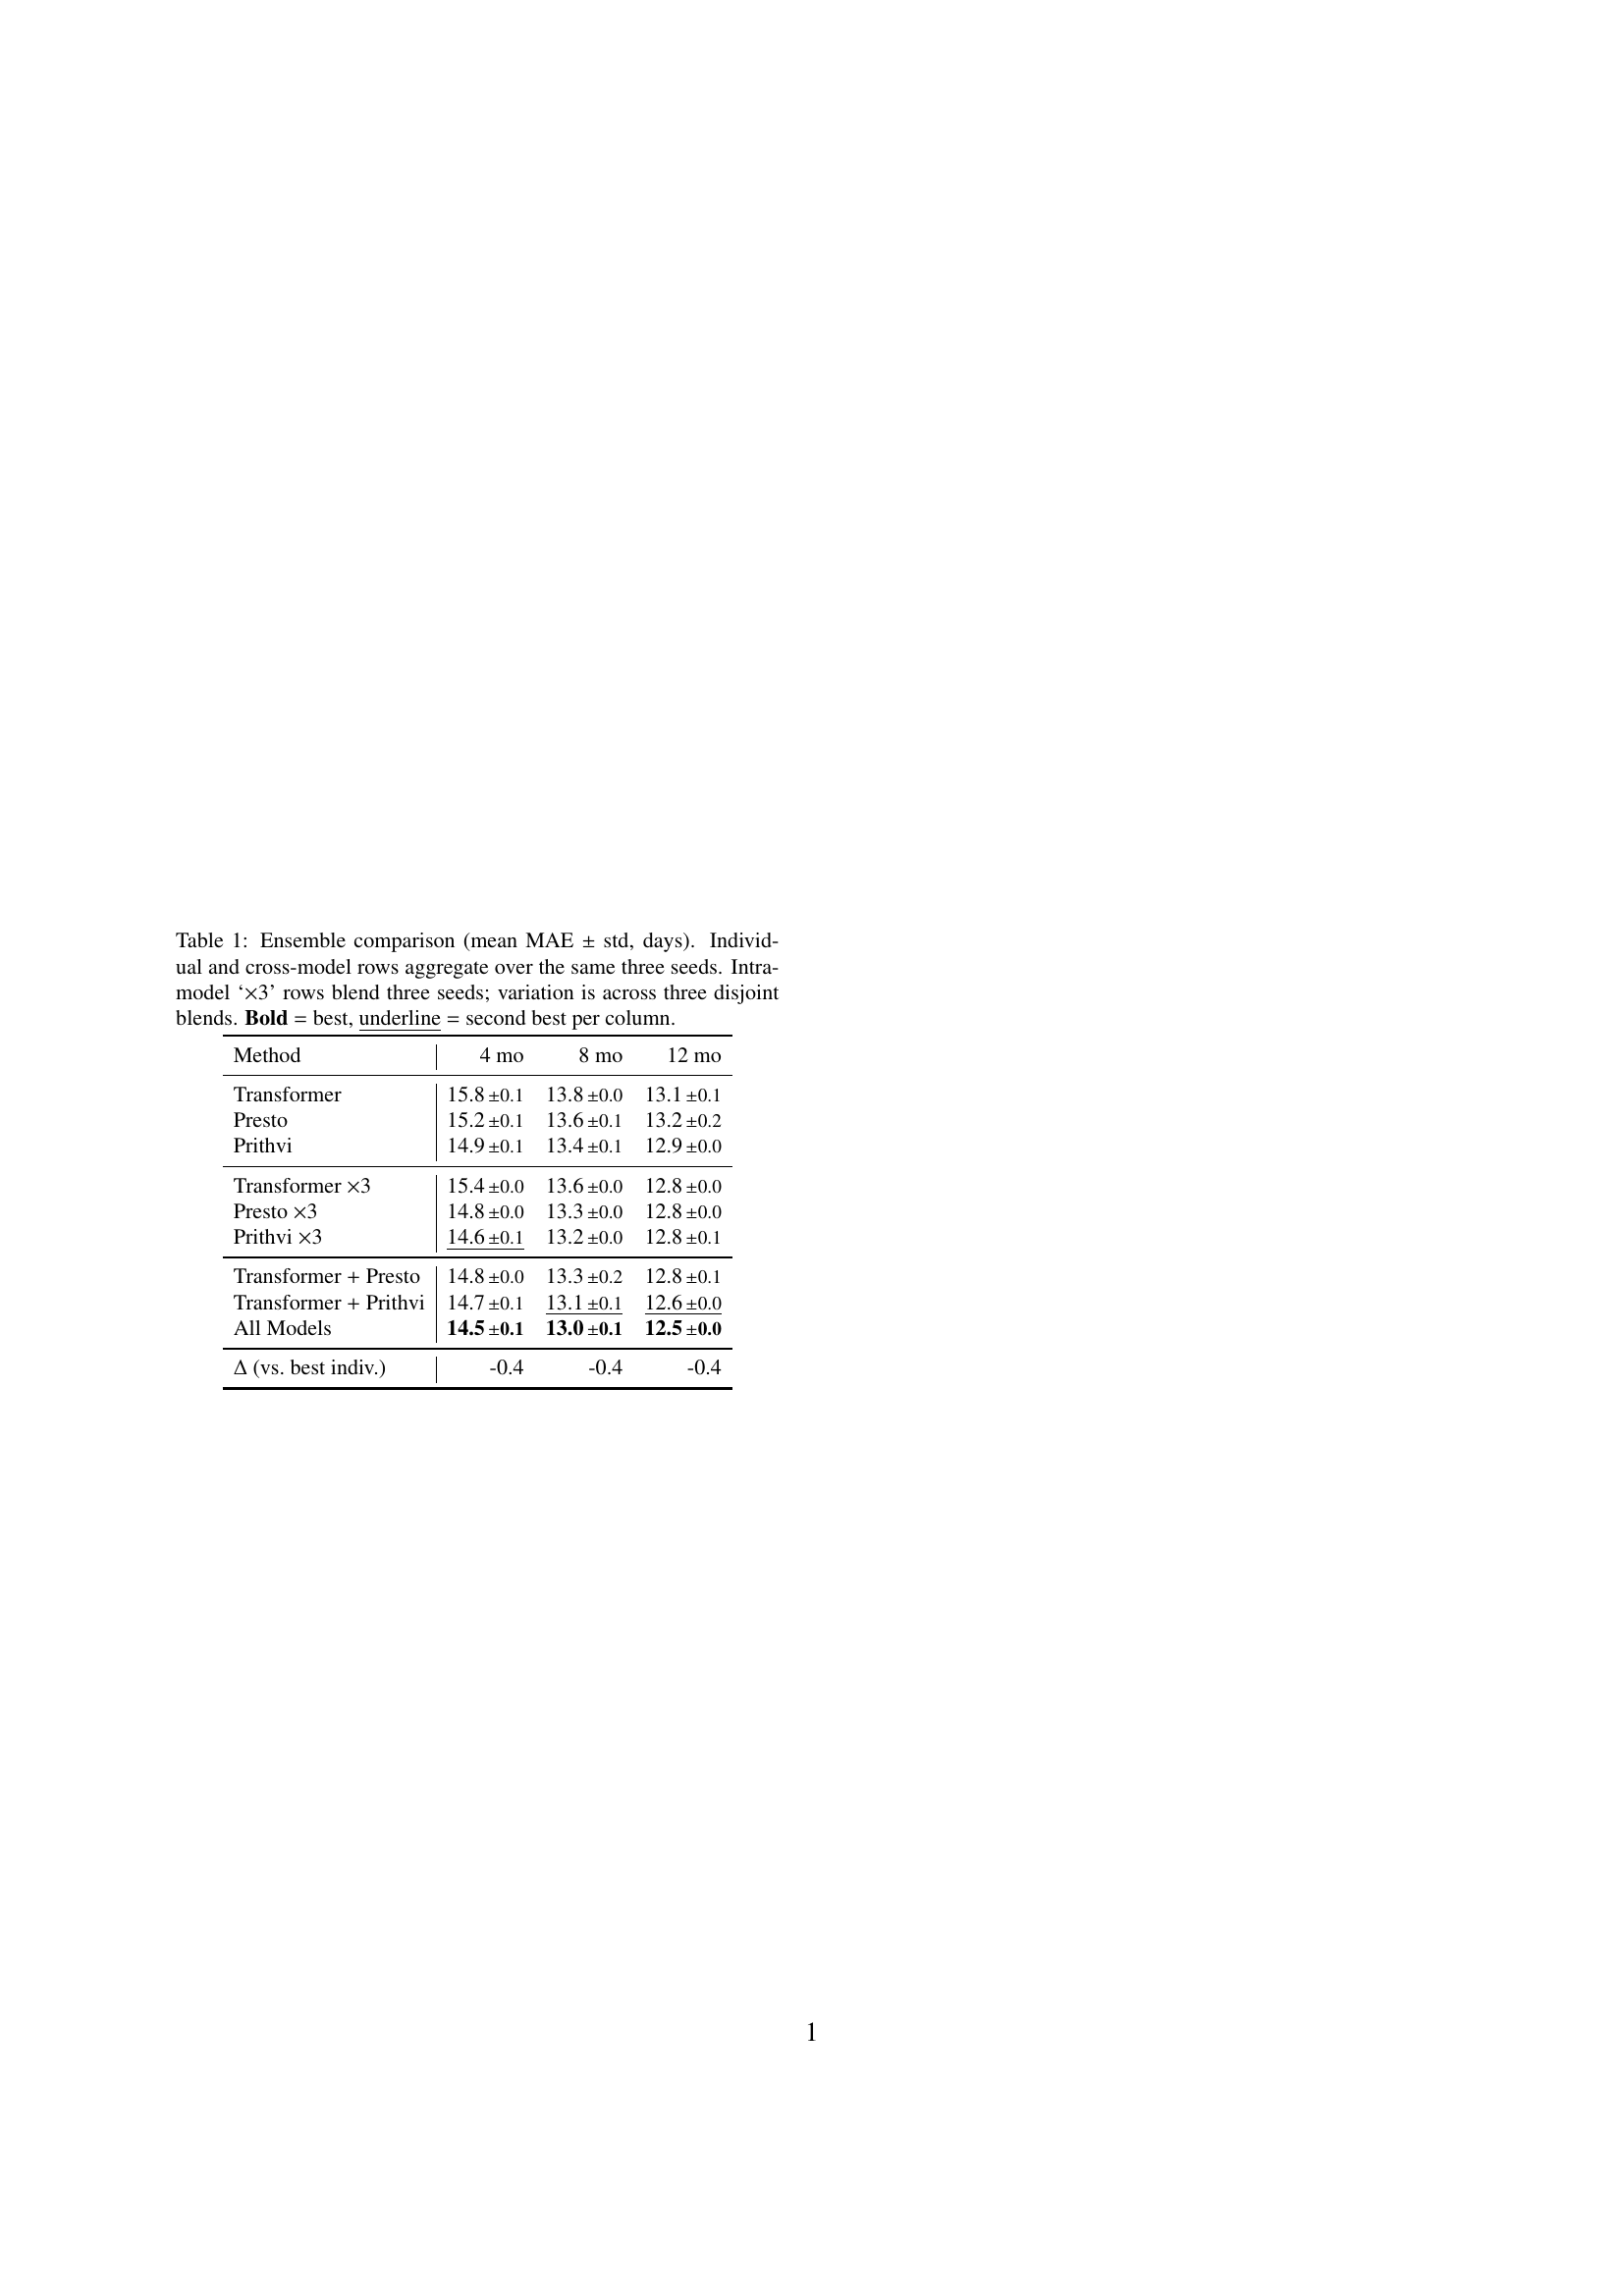

In [14]:
from collections import OrderedDict


def collect_seed_samples(per_seed_dict, keys):
    """Collect Mean / G / M / S / D MAE for each per-seed CSV across the given keys.
    Returns a list of dicts (one per seed CSV across all keys)."""
    samples = []
    for key in keys:
        seed_dfs = per_seed_dict.get(key, [])
        for sdf in seed_dfs:
            tile_info = sdf[["HLStile", "SiteID", "years"]].drop_duplicates().values
            date_maes = {d: [] for d in DATE_NAMES}
            for tile, sid, yr in tile_info:
                df_t = sdf[(sdf["HLStile"] == tile) & (sdf["SiteID"] == sid) & (sdf["years"] == yr)]
                for d_name, d_short in zip(DATE_NAMES, DATE_SHORT):
                    date_maes[d_name].append(np.mean(np.abs(
                        df_t[f"{d_short}_pred_DOY"] - df_t[f"{d_short}_truth_DOY"])))
            sm = {d: np.mean(date_maes[d]) for d in DATE_NAMES}
            sm["Mean"] = np.mean([sm[d] for d in DATE_NAMES])
            samples.append(sm)
    return samples


# Each row maps to a list of method keys whose per-seed CSVs are pooled into samples.
# Individual and cross-model rows use the same three canonical seeds.
# Intra-model rows blend three seeds; each model has three disjoint repeats (gA/gB/gC).
ensemble_rows = OrderedDict([
    ("Transformer",                ["transformer_1d_paper_nl3_1.0_test"]),
    ("Presto",                     ["presto_1.0_test"]),
    ("Prithvi",                    ["prithvi_final_100m_crop32_1.0_test"]),
    ("Transformer \\texttimes 3",  [f"transformer_1d_paper_nl3_1.0_seed_ensemble_g{g}_test" for g in "ABC"]),
    ("Presto \\texttimes 3",       [f"presto_1.0_seed_ensemble_g{g}_test" for g in "ABC"]),
    ("Prithvi \\texttimes 3",      [f"prithvi_final_100m_crop32_1.0_seed_ensemble_g{g}_test" for g in "ABC"]),
    ("Transformer + Presto",       ["ensemble_transformer_presto_test"]),
    ("Transformer + Prithvi",      ["ensemble_transformer_prithvi_test"]),
    ("All Models",                 ["ensemble_all_test"]),
])

month_labels = {4: "4 mo", 8: "8 mo", 12: "12 mo"}
month_keys = sorted(MONTH_SUBSETS.keys())

# stats[label][n_months] = (mean, std, n_samples)
stats = {label: {} for label in ensemble_rows}
for nm in month_keys:
    per_seed = all_results_per_seed.get(nm, {})
    for label, keys in ensemble_rows.items():
        samples = collect_seed_samples(per_seed, keys)
        if not samples:
            continue
        means = np.array([s["Mean"] for s in samples])
        m  = float(np.mean(means))
        sd = float(np.std(means, ddof=1)) if len(means) > 1 else 0.0
        stats[label][nm] = (m, sd, len(means))

# Best / second per column based on mean only (ignore std for ranking)
fmt_info = {}
for nm in month_keys:
    vals = [(label, stats[label][nm][0]) for label in ensemble_rows if nm in stats[label]]
    vals.sort(key=lambda x: x[1])
    if len(vals) >= 1: fmt_info[(vals[0][0], nm)] = "best"
    if len(vals) >= 2: fmt_info[(vals[1][0], nm)] = "second"

# Best individual model mean per month (for Δ row)
individual_labels = ["Transformer", "Presto", "Prithvi"]
best_individual = {}
for nm in month_keys:
    vals = [stats[label][nm][0] for label in individual_labels if nm in stats[label]]
    if vals:
        best_individual[nm] = min(vals)

# Build LaTeX table
L = []
L.append(r"\begin{table}[!t]")
L.append(r"\centering")
L.append(r"\footnotesize")
L.append(r"\setlength{\tabcolsep}{4pt}")
L.append(r"\caption{Ensemble comparison (mean MAE $\pm$ std, days). "
         r"Individual and cross-model rows aggregate over the same three seeds. "
         r"Intra-model `$\times 3$' rows blend three seeds; variation is across three disjoint blends. "
         r"\textbf{Bold} = best, \underline{underline} = second best per column.}")
L.append(r"\label{tab:ensemble_comparison}")
L.append(r"\begin{tabular}{l|rrr}")
L.append(r"\toprule")
L.append(r"Method & " + " & ".join(month_labels[n] for n in month_keys) + r" \\")
L.append(r"\midrule")

groups = [
    ("Individual",       individual_labels),
    ("Intra-model ens.", ["Transformer \\texttimes 3", "Presto \\texttimes 3", "Prithvi \\texttimes 3"]),
    ("Cross-model ens.", ["Transformer + Presto", "Transformer + Prithvi", "All Models"]),
]

for gi, (_, group_methods) in enumerate(groups):
    if gi > 0:
        L.append(r"\midrule")
    for label in group_methods:
        if not stats.get(label):
            continue
        cells = [label]
        for nm in month_keys:
            if nm not in stats[label]:
                cells.append("---")
                continue
            m, sd, n = stats[label][nm]
            txt = f"{m:.1f}{{\\scriptsize\\,$\\pm${sd:.1f}}}"
            fmt = fmt_info.get((label, nm), "")
            if fmt == "best":
                cells.append(r"\textbf{" + txt + "}")
            elif fmt == "second":
                cells.append(r"\underline{" + txt + "}")
            else:
                cells.append(txt)
        L.append(" & ".join(cells) + r" \\")

# Δ vs. best individual
L.append(r"\midrule")
cells = [r"$\Delta$ (vs.\ best indiv.)"]
for nm in month_keys:
    ens = stats.get("All Models", {}).get(nm)
    if ens is None or nm not in best_individual:
        cells.append("---")
        continue
    cells.append(f"{ens[0] - best_individual[nm]:+.1f}")
L.append(" & ".join(cells) + r" \\")

L.append(r"\bottomrule")
L.append(r"\end{tabular}")
L.append(r"\end{table}")

latex_str = "\n".join(L)

render_latex_preview(latex_str)

with open("paper_latex/Tables/ensemble_comparison.tex", "w") as f:
    f.write(latex_str)


## 10. Performance vs. Number of Missing Timesteps

How does prediction quality change as more input timesteps are missing?

MAE is averaged first within each tile-year, then across tile-years within each seed, and finally across seeds. Tile-year/missingness groups must contain at least 25 sampled pixels, and plotted categories must contain at least five qualifying tile-years. Error bars show standard deviation across seeds; gray bars show the number of contributing tile-years.

In [15]:
methods_missing = {
    "Temporal Transformer": "transformer_1d_paper_nl3_1.0_test",
    "Presto":               "presto_1.0_test",
    "Prithvi":              "prithvi_final_100m_crop32_1.0_test",
}

n_months_list = sorted(MONTH_SUBSETS.keys())
subset_labels = {4: "4 Months", 8: "8 Months", 12: "12 Months"}
MAX_MISSING_BY_MONTHS = {4: 1, 8: 2, 12: 3}

MIN_PIXELS_PER_TILE_BIN = 25
MIN_TILES = 5

# Build missing-timestep data for all subsets
all_missing_dfs = {}
for n_months in n_months_list:
    missing_rows = []
    for method_label, method_key in methods_missing.items():
        seed_dfs = all_results_per_seed[n_months].get(method_key, [])
        if not seed_dfs:
            continue

        # First average pixels within each tile-year and missingness bin.
        seed_tile_rows = []
        for seed_idx, seed_df in enumerate(seed_dfs):
            df = seed_df.copy()
            for d_short in DATE_SHORT:
                valid = df[f"{d_short}_truth_DOY"] >= 0
                df[f"{d_short}_AE"] = np.where(
                    valid,
                    np.abs(df[f"{d_short}_pred_DOY"] - df[f"{d_short}_truth_DOY"]),
                    np.nan,
                )

            tile_cols = ["HLStile", "SiteID", "years", "n_missing_ts"]
            for tile_key, grp in df.groupby(tile_cols):
                tile, siteid, year, n_miss = tile_key
                date_maes = {d_name: grp[f"{d_short}_AE"].mean()
                             for d_name, d_short in zip(DATE_NAMES, DATE_SHORT)}
                seed_tile_rows.append({
                    "seed": seed_idx, "HLStile": tile, "SiteID": siteid,
                    "years": year, "n_missing_ts": int(n_miss),
                    "n_pixels": len(grp), **date_maes,
                    "Mean": np.nanmean(list(date_maes.values())),
                })

        seed_tile_df = pd.DataFrame(seed_tile_rows)
        seed_tile_df = seed_tile_df[
            seed_tile_df["n_pixels"] >= MIN_PIXELS_PER_TILE_BIN
        ].copy()
        # Then average tile-years within each seed, followed by seeds.
        for n_miss, miss_df in seed_tile_df.groupby("n_missing_ts"):
            n_tiles = miss_df[["HLStile", "SiteID", "years"]].drop_duplicates().shape[0]
            n_pixels = int(miss_df[miss_df["seed"] == 0]["n_pixels"].sum())
            for date_name in DATE_NAMES + ["Mean"]:
                seed_maes = miss_df.groupby("seed")[date_name].mean()
                missing_rows.append({
                    "Method": method_label, "Date": date_name,
                    "n_missing_ts": int(n_miss),
                    "MAE": seed_maes.mean(),
                    "STD": seed_maes.std(ddof=1) if len(seed_maes) > 1 else 0.0,
                    "n_tiles": n_tiles, "n_pixels": n_pixels,
                    "n_seeds": len(seed_maes),
                })
    all_missing_dfs[n_months] = pd.DataFrame(missing_rows)

# --- Plot (match main-figure style) ---
sns.set_theme(style="whitegrid")

# Same colors as the main figure: Set2 palette indexed by model role
set2 = sns.color_palette("Set2", 4)
method_colors = {
    "Temporal Transformer": set2[0],  # green
    "Presto":               set2[1],  # orange
    "Prithvi":              set2[2],  # blue
}

fig, axes = plt.subplots(1, len(n_months_list),
                         figsize=(6 * len(n_months_list), 5), sharey=True)

for col_idx, n_months in enumerate(n_months_list):
    ax = axes[col_idx]
    ax2 = ax.twinx()
    ax2.grid(False)
    mdf_miss = all_missing_dfs[n_months]

    first_method = list(methods_missing.keys())[0]
    count_sub = mdf_miss[(mdf_miss["Method"] == first_method) & (mdf_miss["Date"] == "Mean")].sort_values("n_missing_ts")
    count_sub = count_sub[count_sub["n_tiles"] >= MIN_TILES]
    count_sub = count_sub[
        count_sub["n_missing_ts"] <= MAX_MISSING_BY_MONTHS[n_months]
    ]
    valid_ts = sorted(count_sub["n_missing_ts"].values)
    max_miss = max(valid_ts) if valid_ts else 0

    if len(count_sub) > 0:
        ax2.bar(count_sub["n_missing_ts"], count_sub["n_tiles"],
                alpha=0.15, color="gray", width=0.8, zorder=1)
        if col_idx == len(n_months_list) - 1:
            ax2.set_ylabel("# Tile-years", fontsize=14, color="gray")
        ax2.tick_params(axis="y", labelsize=12, labelcolor="gray")
        if col_idx < len(n_months_list) - 1:
            ax2.set_yticklabels([])

    for method_label in methods_missing.keys():
        m_sub = mdf_miss[(mdf_miss["Method"] == method_label) & (mdf_miss["Date"] == "Mean")].sort_values("n_missing_ts")
        m_sub = m_sub[m_sub["n_missing_ts"].isin(valid_ts)]
        if len(m_sub) == 0:
            continue
        ax.errorbar(m_sub["n_missing_ts"], m_sub["MAE"], yerr=m_sub["STD"], marker="o",
                label=method_label if col_idx == 0 else None,
                color=method_colors[method_label], linewidth=2, markersize=8,
                capsize=3, elinewidth=1, zorder=3)

    ax.set_title(f"{subset_labels[n_months]}", fontsize=16, fontweight="bold")
    ax.set_xlabel("# Missing Timesteps", fontsize=14)
    ax.set_xticks(valid_ts)
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xlim(-0.5, max_miss + 0.5)

    # Fine-grained y grid: major every 1, minor every 0.5
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax.grid(axis="y", which="major", linestyle="-", linewidth=0.8, alpha=0.5, color="#888888")
    ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.5, alpha=0.4, color="#aaaaaa")
    ax.set_axisbelow(True)

    if col_idx == 0:
        ax.set_ylabel("Mean MAE (days)", fontsize=14)

fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center",
           ncol=len(methods_missing), bbox_to_anchor=(0.5, -0.06), fontsize=14)
plt.tight_layout()
plt.show()


In [16]:
fig.savefig("paper_latex/Images/missing_timesteps.pdf", bbox_inches="tight", dpi=300)
print("Saved: paper_latex/Images/missing_timesteps.pdf")

Saved: paper_latex/Images/missing_timesteps.pdf
